# EDA — Banca Activo

---
## 0. Configuración del Dataset

In [1]:
# ============================================================
# CONFIGURACIÓN: BANCA_ACTIVO
# ============================================================

DATASET_CONFIG = {
    'nombre': 'banca_activo',
    'archivo': 'ed_activo_historico_1962_2026.csv',
'frecuencia_original': 'mensual',
    'col_fecha': 'fecha',
    'variable_principal': 'ed_activo_total',
    'variables_desgloses': [
        'ed_activo_credito_sector_privado',
        'ed_activo_credito_sector_publico',
        'ed_activo_creditos_esp',
    ],
    'columnas_numericas': [
        'ed_activo_total',
        'ed_activo_creditos_esp',
        'ed_activo_credito_sector_publico',
        'ed_activo_credito_sector_privado',
        'ed_activo_creditos_resto_mundo',
        'ed_activo_renta_fija_esp',
        'ed_activo_efectivo',
    ],
    'unidades': 'millones EUR constantes 2025',
    'notas': 'Banco de España. Entidades de depósito: activo. Mensual desde 1962.',
}

VAR_PRINCIPAL = DATASET_CONFIG['variable_principal']
NOMBRE        = DATASET_CONFIG['nombre']
UNIDADES      = DATASET_CONFIG['unidades']

PERIODO_ESTACIONAL = {
    'trimestral': 4,
    'mensual': 12,
    'diaria': 365,
}[DATASET_CONFIG['frecuencia_original']]

LAGS_ACF = {
    'trimestral': 16,
    'mensual': 36,
    'diaria': 60,
}[DATASET_CONFIG['frecuencia_original']]

print(f'Dataset configurado: {NOMBRE}')
print(f'Variable principal:  {VAR_PRINCIPAL}')
print(f'Frecuencia:          {DATASET_CONFIG["frecuencia_original"]}')
print(f'Periodo estacional:  {PERIODO_ESTACIONAL}')

Dataset configurado: banca_activo
Variable principal:  ed_activo_total
Frecuencia:          mensual
Periodo estacional:  12


---
## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import warnings
from pathlib import Path
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

RUTA_BASE = Path(r'C:\Users\marco\PycharmProjects\TFM_Marcos\Datasets')

COLOR_PRINCIPAL = '#5E35B1'
COLORES_DESGLOSES = ['#00897B', '#FF7043', '#FFC107', '#1565C0', '#AD1457']

EVENTOS = {
    '1986-01-01': 'Entrada UE',
    '1999-01-01': 'Euro',
    '2008-09-01': 'Crisis\nfinanciera',
    '2012-01-01': 'Crisis\ndeuda',
    '2020-03-01': 'COVID-19',
}

---
## 1. Carga y Diagnóstico Básico

In [3]:
ruta = RUTA_BASE / DATASET_CONFIG['archivo']
df = pd.read_csv(ruta)
df[DATASET_CONFIG['col_fecha']] = pd.to_datetime(df[DATASET_CONFIG['col_fecha']])
df = df.set_index(DATASET_CONFIG['col_fecha']).sort_index()

for col in DATASET_CONFIG['columnas_numericas']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset: {NOMBRE}')
print(f'Notas:   {DATASET_CONFIG["notas"]}')
print('=' * 60)
print(f'Shape:          {df.shape}')
print(f'Rango temporal: {df.index.min().date()} a {df.index.max().date()}')
print(f'Observaciones:  {len(df)}')
print(f'Columnas:       {list(df.columns)}')

Dataset: banca_activo
Notas:   Banco de España. Entidades de depósito: activo. Mensual desde 1962.
Shape:          (616, 13)
Rango temporal: 1974-07-01 a 2025-10-01
Observaciones:  616
Columnas:       ['año', 'mes', 'ed_activo_total', 'ed_activo_creditos_esp', 'ed_activo_credito_sector_publico', 'ed_activo_credito_sector_privado', 'ed_activo_creditos_resto_mundo', 'ed_activo_renta_fija_esp', 'ed_activo_renta_fija_resto_mundo', 'ed_activo_acciones_esp', 'ed_activo_acciones_resto_mundo', 'ed_activo_efectivo', 'ed_activo_otros_residual']


In [4]:
print('Primeras 3 filas:')
display(df.head(3))
print('\nÚltimas 3 filas:')
display(df.tail(3))

Primeras 3 filas:


,año,mes,ed_activo_total,ed_activo_creditos_esp,ed_activo_credito_sector_publico,ed_activo_credito_sector_privado,ed_activo_creditos_resto_mundo,ed_activo_renta_fija_esp,ed_activo_renta_fija_resto_mundo,ed_activo_acciones_esp,ed_activo_acciones_resto_mundo,ed_activo_efectivo,ed_activo_otros_residual
fecha,,,,,,,,,,,,,
1974-07-01,1974,7,458994.060,62652.168,924.725,316725.104,22099.975,NaN,NaN,18475.102,432.262,5829.444,31855.282
1974-08-01,1974,8,446365.715,61928.028,471.007,311578.160,20017.290,NaN,NaN,17874.235,379.806,5154.510,28962.679
1974-09-01,1974,9,445449.785,63345.821,465.129,310781.214,18036.183,NaN,NaN,17856.956,389.355,4811.248,29763.880



Últimas 3 filas:


,año,mes,ed_activo_total,ed_activo_creditos_esp,ed_activo_credito_sector_publico,ed_activo_credito_sector_privado,ed_activo_creditos_resto_mundo,ed_activo_renta_fija_esp,ed_activo_renta_fija_resto_mundo,ed_activo_acciones_esp,ed_activo_acciones_resto_mundo,ed_activo_efectivo,ed_activo_otros_residual
fecha,,,,,,,,,,,,,
2025-08-01,2025,8,3075660.408,300422.622,83231.384,1152753.766,575812.712,264385.048,174542.382,131820.497,119543.592,7202.411,265945.994
2025-09-01,2025,9,3078678.352,292900.906,82367.688,1157289.245,566486.848,267290.968,183409.212,132431.559,121768.518,7021.559,267711.850
2025-10-01,2025,10,3103338.300,278844.330,81474.293,1155072.937,607556.491,262860.700,186359.235,130073.417,123241.348,7090.999,270764.549


In [5]:
cols_num = DATASET_CONFIG['columnas_numericas']
cols_num = [c for c in cols_num if c in df.columns]

nulos = pd.DataFrame({
    'n_nulos': df[cols_num].isnull().sum(),
    'pct_nulos': df[cols_num].isnull().mean() * 100,
    'primer_valido': [df[c].first_valid_index() for c in cols_num],
    'ultimo_valido': [df[c].last_valid_index() for c in cols_num],
}).round(2)

print('Diagnóstico de valores faltantes:')
display(nulos)

n_dupl = df.index.duplicated().sum()
print(f'\nDuplicados de fecha: {n_dupl}')

Diagnóstico de valores faltantes:


,n_nulos,pct_nulos,primer_valido,ultimo_valido
ed_activo_total,0,0.000,1974-07-01,2025-10-01
ed_activo_creditos_esp,0,0.000,1974-07-01,2025-10-01
ed_activo_credito_sector_publico,0,0.000,1974-07-01,2025-10-01
ed_activo_credito_sector_privado,0,0.000,1974-07-01,2025-10-01
ed_activo_creditos_resto_mundo,0,0.000,1974-07-01,2025-10-01
ed_activo_renta_fija_esp,77,12.500,1980-12-01,2025-10-01
ed_activo_efectivo,0,0.000,1974-07-01,2025-10-01



Duplicados de fecha: 0


In [6]:
if len(df) > 1:
    diffs = df.index.to_series().diff().dropna()
    print(f'Intervalo mediano entre observaciones: {diffs.median()}')
    print(f'Intervalo mínimo:                      {diffs.min()}')
    print(f'Intervalo máximo:                      {diffs.max()}')

    umbral = diffs.median() * 2
    huecos = diffs[diffs > umbral]
    if len(huecos) > 0:
        print(f'\nHuecos temporales detectados ({len(huecos)}):')
        print(huecos)

Intervalo mediano entre observaciones: 31 days 00:00:00
Intervalo mínimo:                      28 days 00:00:00
Intervalo máximo:                      31 days 00:00:00


---
## 2. Series Temporales

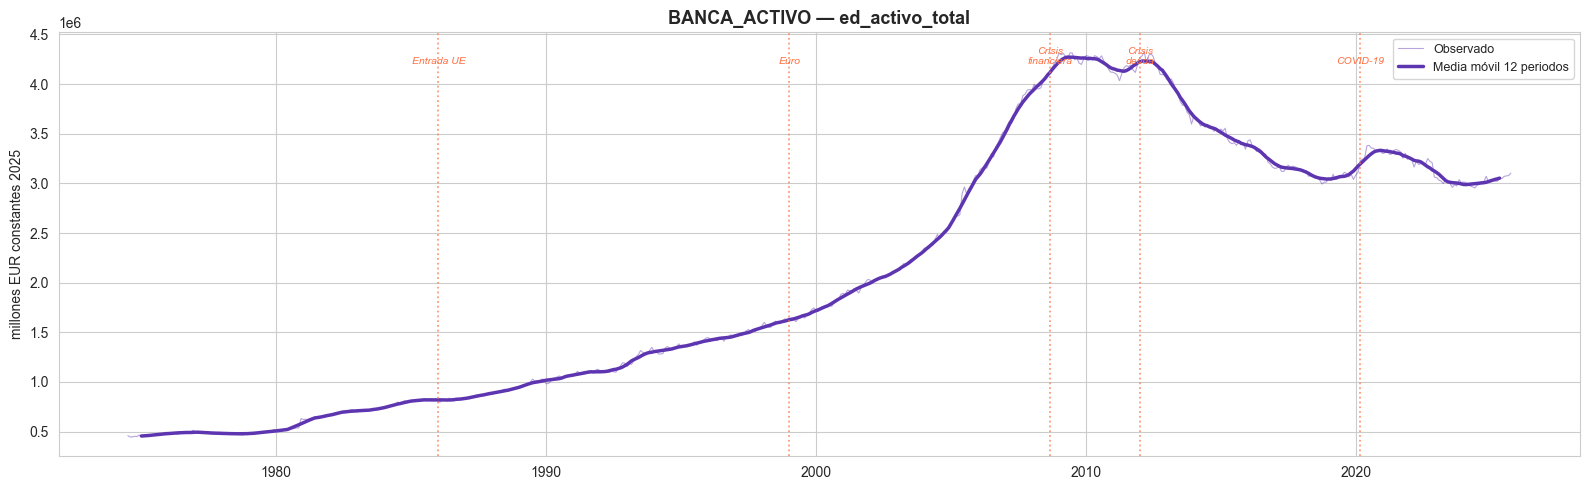

Mín: 445449.78  (1974-09-01)
Máx: 4327079.85  (2012-03-01)


In [7]:
ventana_mm = PERIODO_ESTACIONAL

fig, ax = plt.subplots(figsize=(16, 5))

y = df[VAR_PRINCIPAL].dropna()
mm = y.rolling(ventana_mm, center=True).mean()

ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=0.8, alpha=0.45, label='Observado')
ax.plot(y.index, mm, color=COLOR_PRINCIPAL, lw=2.5,
        label=f'Media móvil {ventana_mm} periodos')

y_max = y.max()
for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if y.index.min() <= fecha_ev <= y.index.max():
        ax.axvline(fecha_ev, color='#FF7043', linestyle=':', lw=1.3, alpha=0.7)
        ax.text(fecha_ev, y_max * 0.97, texto,
                ha='center', fontsize=7.5, color='#FF7043', fontstyle='italic')

ax.set_title(f'{NOMBRE.upper()} — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')
ax.set_ylabel(UNIDADES, fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mín: {y.min():.2f}  ({y.idxmin().date()})')
print(f'Máx: {y.max():.2f}  ({y.idxmax().date()})')

### Análisis:

El activo total del sistema bancario español (`ed_activo_total`) describe una de las expansiones más llamativas de toda la base de datos: desde un mínimo de 466.135 millones en octubre de 1978 hasta un máximo de 4.327.080 millones en marzo de 2012, multiplicando por un factor de aproximadamente 9,3 en términos reales a precios constantes de 2025 en poco más de tres décadas.

La trayectoria se articula en tres fases. La primera, entre 1975 y 1999, es de crecimiento gradual y sostenido desde aproximadamente 500.000 millones hasta 1.700.000 millones, con una ligera aceleración visible tras la entrada en la CEE en 1986 y una nueva aceleración a partir de 1999 con la adopción del euro, que eliminó el riesgo cambiario y facilitó el acceso de la banca española a los mercados mayoristas de financiación europeos. La segunda, entre 1999 y 2012, es la más explosiva: el activo total se multiplica por 2,5 en apenas 13 años, impulsado por el boom del crédito hipotecario y la burbuja inmobiliaria, la expansión internacional de los grandes grupos bancarios españoles y el apalancamiento masivo del sistema financiero. El máximo de 4.327.080 millones en marzo de 2012 coincide con el pico de la crisis de deuda soberana y el inicio del proceso de reestructuración bancaria española. La tercera fase, desde 2012, describe un desapalancamiento progresivo hasta aproximadamente 3.000.000-3.100.000 millones en 2025, con una recuperación temporal en 2021-2022 probablemente asociada a los avales ICO y la expansión del crédito post-pandémico.

Para la modelización del paro, el activo bancario opera como proxy del crédito disponible en la economía: la expansión del balance bancario facilita la financiación de la inversión empresarial y el consumo, sosteniendo el empleo, mientras el desapalancamiento bancario contrae el crédito y restringe la capacidad de las empresas de mantener plantillas. El ciclo 1999-2012 es el ejemplo más claro de este mecanismo en la muestra.

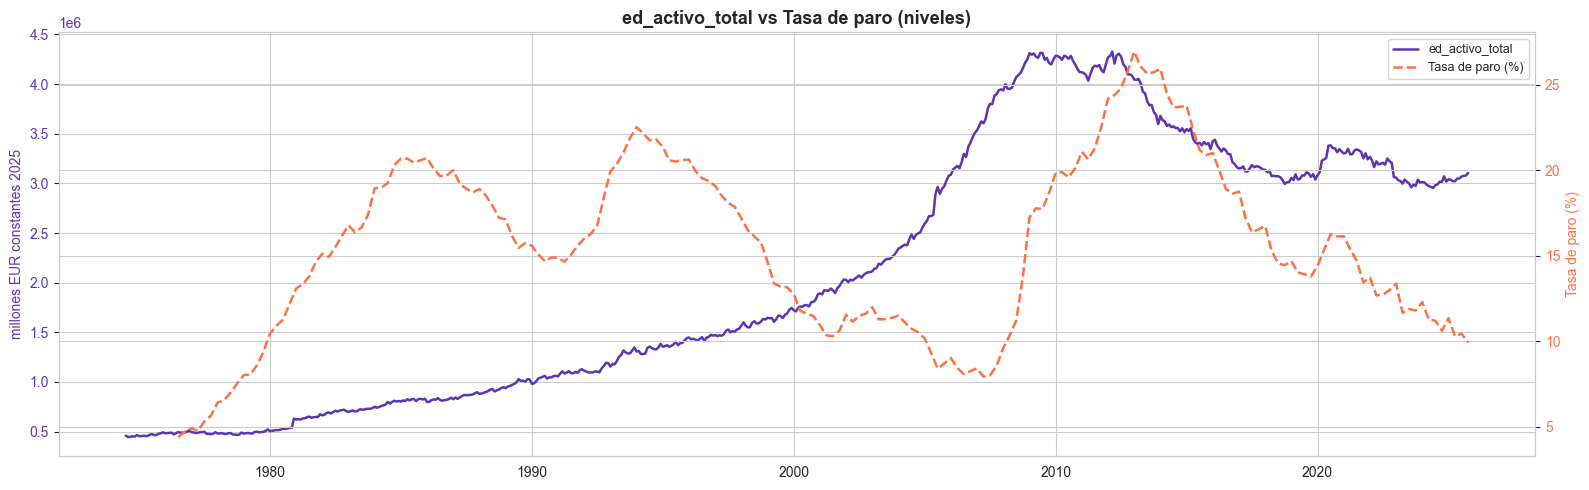

In [8]:
# Comparación de niveles con la tasa de paro (antes de analizar estacionariedad)
ruta_paro_s2 = RUTA_BASE / 'parados_sexo_edad.csv'
df_paro_s2 = pd.read_csv(ruta_paro_s2)
df_paro_s2['fecha'] = pd.to_datetime(df_paro_s2['fecha'])
df_paro_s2 = df_paro_s2.set_index('fecha').sort_index()
tasa_paro_s2 = pd.to_numeric(df_paro_s2['tasa_paro_ambos_sexos_total'], errors='coerce').dropna()

y = df[VAR_PRINCIPAL].dropna()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax1.plot(y.index, y, color=COLOR_PRINCIPAL, lw=1.8, label=VAR_PRINCIPAL)
ax2.plot(tasa_paro_s2.index, tasa_paro_s2, color='#FF7043', lw=1.8, linestyle='--', label='Tasa de paro (%)')
ax1.set_ylabel(UNIDADES, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')
ax1.set_title(f'{VAR_PRINCIPAL} vs Tasa de paro (niveles)', fontsize=13, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc='best')
plt.tight_layout()
plt.show()


### Análisis:

La comparación en niveles entre `ed_activo_total` y la tasa de paro muestra un co-movimiento cuyo signo cambia a lo largo del periodo. Entre 1974 y 1985 las dos series suben conjuntamente: el paro recorre de aproximadamente el 5% al 21% mientras el activo bancario crece de aproximadamente 0,45 a 0,7 billones EUR constantes de 2025, con un co-movimiento positivo asociado a la fase de ajuste posterior a la crisis del petróleo.

Entre 1985 y 2007 la relación se invierte. El activo crece de forma sostenida hasta aproximadamente 4,3 billones mientras el paro alterna dos máximos próximos al 21% en 1985 y al 23% en 1994 y desciende hasta el mínimo de aproximadamente el 8% en 2007. Las dos series se cruzan visualmente en torno al año 2000 y el co-movimiento es negativo durante todo el tramo, coincidente con la expansión crediticia previa a la crisis financiera.

Entre 2007 y 2013 vuelve a aparecer co-movimiento positivo: el activo alcanza su máximo de aproximadamente 4,33 billones en 2012 y el paro su máximo de aproximadamente el 27% en 2013, con subida conjunta interrumpida por la inversión del activo al final del tramo. A partir de 2013 ambas series descienden, con el paro hasta aproximadamente el 10% al final de la muestra y el activo estabilizándose en torno a 3 billones desde 2016. El cambio de signo del co-movimiento a lo largo del periodo y el carácter no estacionario de las dos series indican que la relación contemporánea en niveles está dominada por las tendencias compartidas y enmascara la dinámica cíclica subyacente, que se analiza en la sección 9 sobre las formas estacionarias correspondientes.

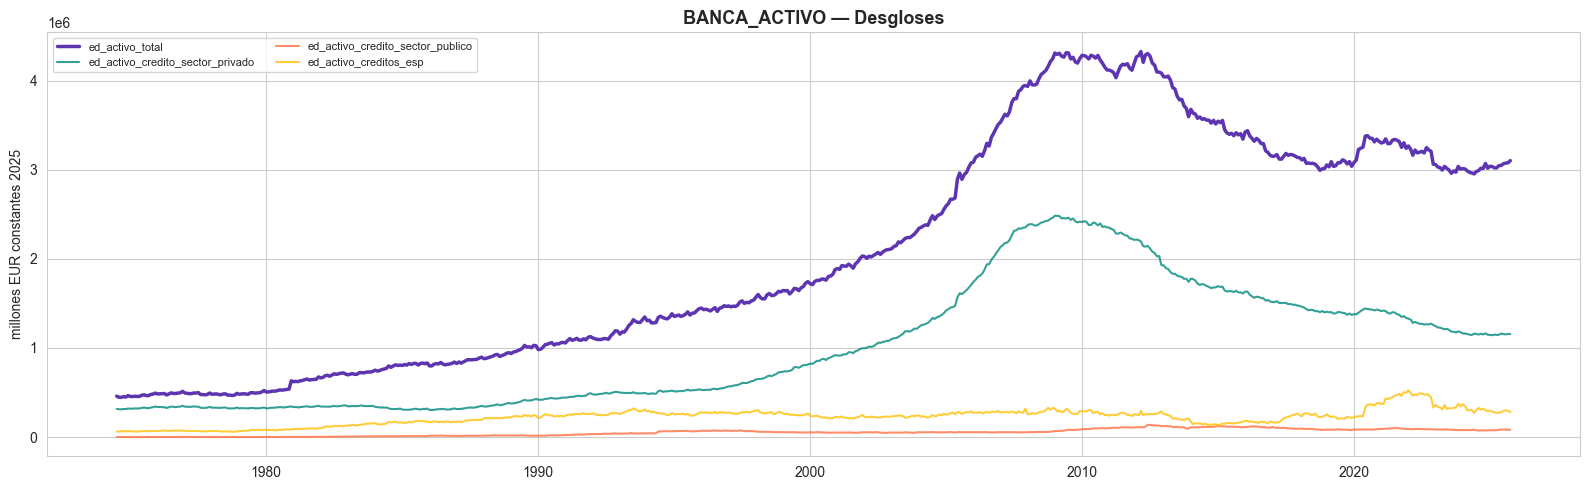

In [9]:
desgloses = [c for c in DATASET_CONFIG.get('variables_desgloses', []) if c in df.columns]

if desgloses:
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=2.5, label=VAR_PRINCIPAL, zorder=5)

    for col, color in zip(desgloses, COLORES_DESGLOSES):
        serie = df[col].dropna()
        ax.plot(serie.index, serie, color=color, lw=1.5, alpha=0.8, label=col)

    ax.set_title(f'{NOMBRE.upper()} — Desgloses', fontsize=13, fontweight='bold')
    ax.set_ylabel(UNIDADES, fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

### Análisis:

El desglose del activo bancario revela que el crédito al sector privado (`ed_activo_credito_sector_privado`) es el componente que explica prácticamente la totalidad de la expansión y contracción del balance total. Desde niveles de aproximadamente 350.000 millones en 1975, el crédito privado crece de forma paralela al total hasta 1999, momento en que se desacopla y acelera bruscamente hasta alcanzar un máximo de aproximadamente 2.500.000 millones en 2009-2010, para contraerse posteriormente hasta aproximadamente 1.200.000 millones en 2025. Esta trayectoria en forma de montaña asimétrica es el reflejo directo del ciclo de expansión y contracción del crédito hipotecario y empresarial asociado a la burbuja inmobiliaria.

La brecha entre el `ed_activo_total` y el `ed_activo_credito_sector_privado`, que se amplía notablemente a partir de 2000 y especialmente entre 2010 y 2025, refleja el crecimiento de otros componentes del activo bancario no capturados en este desglose: activos interbancarios, cartera de deuda pública, activos adjudicados y exposición a mercados internacionales de los grandes grupos bancarios españoles.

El `ed_activo_credito_sector_publico` permanece prácticamente plano y próximo a cero durante toda la muestra hasta 2020, cuando registra un incremento visible aunque moderado, coherente con el aumento de la cartera de deuda soberana de los bancos españoles durante la pandemia. El `ed_activo_creditos_esp` (créditos especiales o dudosos) mantiene niveles bajos durante el largo ciclo expansivo y muestra un repunte en 2020-2022, coherente con el deterioro de la calidad crediticia asociado al impacto económico del confinamiento. Para la modelización del paro, el `ed_activo_credito_sector_privado` es el componente con mayor relevancia: su ciclo de expansión y contracción se sincroniza directamente con los ciclos de creación y destrucción de empleo documentados en el EDA de población.

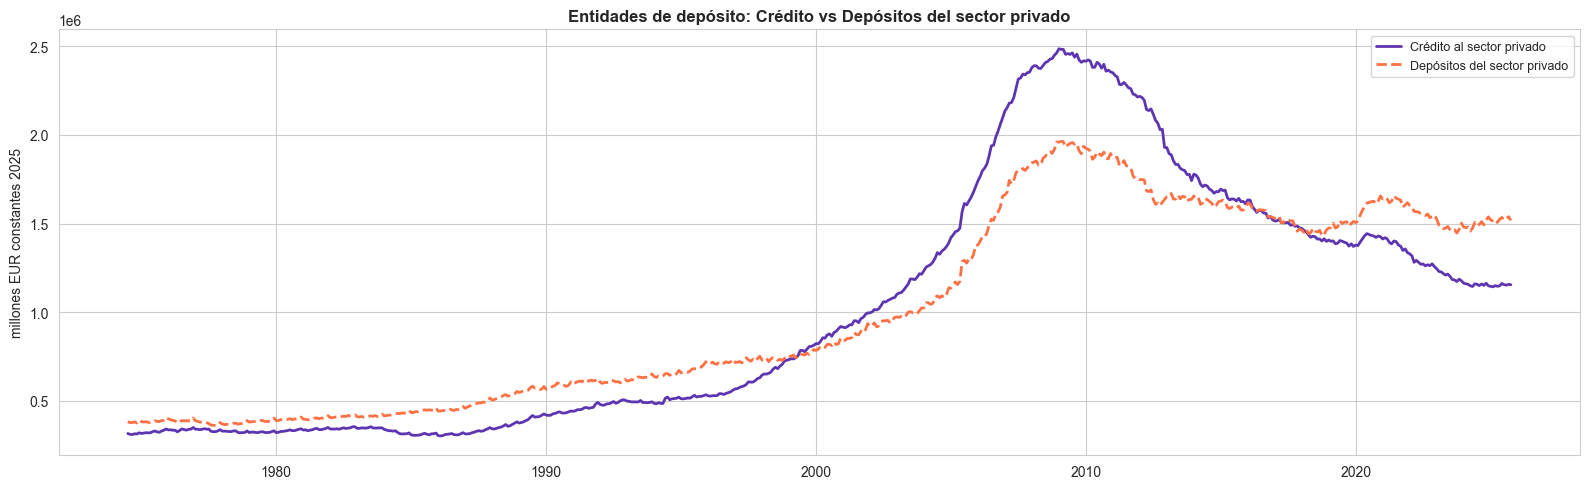

In [10]:
# Crédito vs Depósitos del sector privado
ruta_pasivo = RUTA_BASE / 'ed_pasivo_historico_1962_2026.csv'
df_pasivo = pd.read_csv(ruta_pasivo)
df_pasivo['fecha'] = pd.to_datetime(df_pasivo['fecha'])
df_pasivo = df_pasivo.set_index('fecha').sort_index()
for col in df_pasivo.columns:
    df_pasivo[col] = pd.to_numeric(df_pasivo[col], errors='coerce')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df['ed_activo_credito_sector_privado'].dropna().index,
        df['ed_activo_credito_sector_privado'].dropna(),
        color=COLOR_PRINCIPAL, lw=2, label='Crédito al sector privado')
ax.plot(df_pasivo['ed_pasivo_sector_privado'].dropna().index,
        df_pasivo['ed_pasivo_sector_privado'].dropna(),
        color='#FF7043', lw=2, linestyle='--', label='Depósitos del sector privado')
ax.set_title('Entidades de depósito: Crédito vs Depósitos del sector privado',
             fontsize=12, fontweight='bold')
ax.set_ylabel(UNIDADES, fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Análisis:

La comparación entre crédito y depósitos del sector privado ilustra uno de los desequilibrios más relevantes del sistema bancario español en el periodo analizado. Hasta aproximadamente 1998 ambas series se mueven de forma paralela y prácticamente solapadas, con los depósitos ligeramente por encima del crédito, lo que refleja un modelo bancario tradicional donde la financiación del crédito descansaba fundamentalmente en los depósitos captados de los clientes.

A partir de 1999 las dos series se desacoplan de forma pronunciada: el crédito al sector privado acelera muy por encima de los depósitos, generando una brecha creciente que alcanza su máximo en torno a 2008-2009, cuando el crédito supera los 2.400.000 millones y los depósitos no llegan a 2.000.000 millones. Esta brecha de aproximadamente 400.000-500.000 millones representa el déficit de financiación minorista que la banca española cubrió mediante financiación mayorista en los mercados interbancarios europeos, posibilitada por la eliminación del riesgo cambiario con el euro. La dependencia de esta financiación mayorista fue precisamente el talón de Aquiles del sistema cuando los mercados interbancarios se cerraron tras Lehman en 2008, precipitando la crisis de liquidez bancaria española.

Desde 2012 el desapalancamiento del crédito es más rápido que el de los depósitos, cerrando y finalmente invirtiendo la brecha: al final de la muestra el crédito se sitúa en torno a 1.200.000 millones frente a depósitos de aproximadamente 1.500.000 millones. La relación ha completado un ciclo: depósitos por encima del crédito antes de 1999, crédito por encima de depósitos durante la burbuja (1999-2012), y vuelta a depósitos por encima del crédito desde aproximadamente 2015. Esta inversión refleja la restauración del modelo de financiación minorista tradicional tras el saneamiento del sector, con un exceso de depósitos que indica un sistema bancario menos apalancado y más resistente a shocks de liquidez que en 2008. Para la modelización del paro, la brecha entre crédito y depósitos es una variable derivada de potencial interés como indicador del grado de apalancamiento del sistema bancario y de su vulnerabilidad a episodios de restricción crediticia.

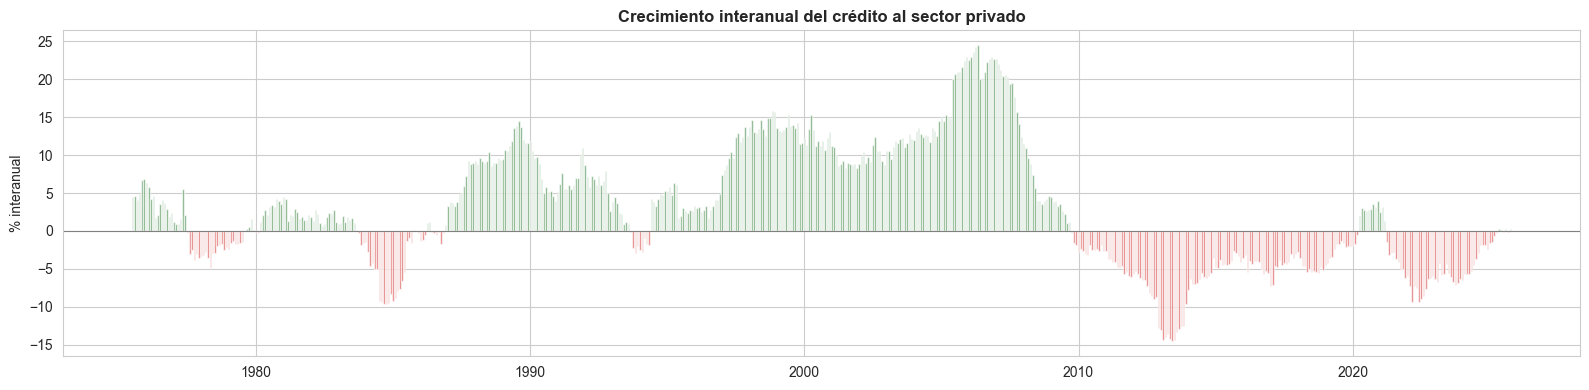

In [11]:
# Crecimiento interanual del crédito al sector privado
if 'ed_activo_credito_sector_privado' in df.columns:
    cred_yoy = df['ed_activo_credito_sector_privado'].pct_change(12) * 100

    fig, ax = plt.subplots(figsize=(16, 4))
    colors = cred_yoy.apply(lambda x: '#2E7D32' if x >= 0 else '#D32F2F')
    ax.bar(cred_yoy.index, cred_yoy, color=colors, alpha=0.7, width=20)
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_title('Crecimiento interanual del crédito al sector privado', fontsize=12, fontweight='bold')
    ax.set_ylabel('% interanual', fontsize=10)
    plt.tight_layout()
    plt.show()

### Análisis:

El crecimiento interanual del crédito al sector privado describe tres ciclos de expansión-contracción con una asimetría creciente en amplitud que culmina en el episodio de la burbuja inmobiliaria.

El primer ciclo (1975-1993) es el más moderado: tasas positivas de entre 0% y 5% durante los años 70, una aceleración hasta aproximadamente 10-15% en el tramo 1987-1991 asociada a la expansión post-CEE, un episodio de contracción de aproximadamente -8% en torno a 1982-1984 durante la reconversión industrial, y otro breve en 1992-1993 coincidiendo con la crisis del SME. El segundo ciclo (1994-2007) es el más intenso de la muestra: el crecimiento se acelera de forma progresiva desde tasas del 5% hasta un máximo de aproximadamente 25% en 2006, la mayor tasa de expansión crediticia de toda la serie. Esta aceleración sostenida durante más de una década sin corrección intermedia es la expresión directa del boom hipotecario y del acceso masivo a financiación mayorista europea documentado en el gráfico anterior.

La contracción posterior a 2008 es la más prolongada y profunda de la muestra: las tasas se vuelven negativas en torno a 2009 y alcanzan un mínimo de aproximadamente -15% en 2013-2014, permaneciendo en terreno negativo de forma casi ininterrumpida hasta 2019. Esta década de contracción crediticia no tiene precedente en la serie y se corresponde exactamente con el periodo de desapalancamiento bancario, reestructuración del sector y destrucción de empleo de la Gran Recesión. El breve repunte positivo de 2020 refleja los avales ICO y el crédito de emergencia pandémico, seguido de una vuelta a terreno negativo de aproximadamente -5% a -10% en 2021-2025 por la continuación del desapalancamiento y las subidas de tipos del BCE. Para la modelización del paro, la variación interanual del crédito privado es una candidata natural como regresor: su ciclo se sincroniza con los ciclos de empleo y su magnitud captura la intensidad de la restricción o expansión financiera de la economía.

---
## 3. Distribución y Outliers

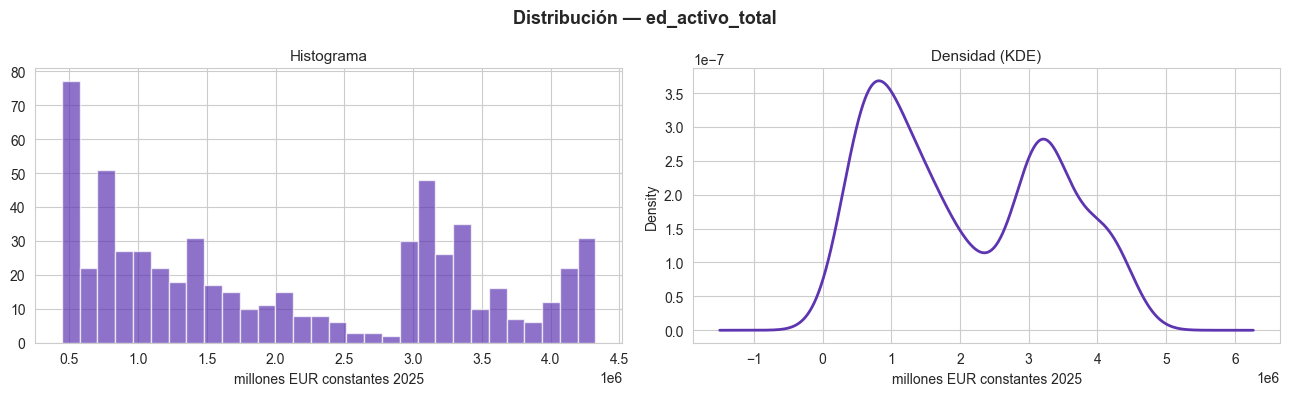

Asimetría (skewness): 0.261
Curtosis:             -1.409


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Distribución — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].hist(y, bins=30, color=COLOR_PRINCIPAL, alpha=0.7, edgecolor='white')
axes[0].set_xlabel(UNIDADES, fontsize=10)
axes[0].set_title('Histograma', fontsize=11)

y.plot.kde(ax=axes[1], color=COLOR_PRINCIPAL, lw=2)
axes[1].set_xlabel(UNIDADES, fontsize=10)
axes[1].set_title('Densidad (KDE)', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Asimetría (skewness): {y.skew():.3f}')
print(f'Curtosis:             {y.kurtosis():.3f}')

### Análisis:

`ed_activo_total` presenta una distribución bimodal con dos masas de observaciones claramente separadas por un valle entre aproximadamente 2.000.000 y 2.500.000 millones. La moda inferior, en torno a 500.000-800.000 millones, concentra la mayor densidad y agrupa las observaciones del largo periodo de crecimiento gradual 1975-2000. La moda superior, en torno a 3.000.000-3.500.000 millones, tiene densidad algo menor pero claramente diferenciada y agrupa las observaciones del periodo 2005-2025, incluyendo tanto el pico de la burbuja como el tramo de desapalancamiento posterior.

La asimetría positiva de 0,261 es moderada y refleja que la cola derecha generada por los valores extremos del pico de 2008-2012 (máximo de 4.327.080 millones) desplaza ligeramente la distribución. La curtosis de -1,409 es el estadístico más informativo: su valor fuertemente negativo confirma la bimodalidad, con la masa repartida entre los dos extremos del rango y escasas observaciones en el centro, un patrón platicúrtico comparable al documentado para el `pib_pm` (-1,496). La similitud entre ambas curtosis no es casual: las dos series comparten una estructura de crecimiento de largo plazo que genera dos masas de observaciones temporales diferenciadas.

La bimodalidad tiene una explicación directa en la serie temporal: el periodo de crecimiento gradual (1975-2000) acumula muchas observaciones a niveles bajos, el periodo de expansión explosiva (2000-2008) cruza rápidamente el valle intermedio sin acumular densidad, y el tramo de desapalancamiento (2012-2025) se estabiliza en la zona de la moda superior sin retornar a los niveles previos a la burbuja. Para la modelización, el nivel del activo bancario no es adecuado como regresor sin transformación: la variación interanual o la primera diferencia son las transformaciones necesarias para eliminar esta estructura bimodal.

In [13]:
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

z_scores = np.abs(stats.zscore(y.dropna()))
outliers_z = y[z_scores > 3]
outliers_iqr = y[(y < limite_inf_iqr) | (y > limite_sup_iqr)]

print(f'Outliers por IQR  (1.5×): {len(outliers_iqr)}')
print(f'Outliers por z-score (>3): {len(outliers_z)}')

extremos = pd.concat([
    y.nsmallest(5).rename('valor'),
    y.nlargest(5).rename('valor')
]).sort_values()

print('\n10 valores extremos (5 mínimos + 5 máximos):')
print(extremos.to_frame().reset_index().to_string(index=False))

Outliers por IQR  (1.5×): 0
Outliers por z-score (>3): 0

10 valores extremos (5 mínimos + 5 máximos):
     fecha       valor
1974-09-01  445449.785
1974-08-01  446365.715
1974-11-01  449007.141
1974-10-01  453577.001
1975-02-01  454394.430
2009-03-01 4308743.569
2009-01-01 4311641.756
2009-07-01 4312269.146
2009-06-01 4314468.100
2012-03-01 4327079.852


### Análisis:

La ausencia de outliers por ambos criterios responde al mismo mecanismo ya documentado para el IPRI y el PIB: la tendencia de largo plazo dilata el rango intercuartílico hasta absorber todos los valores, incluidos los extremos del pico de 2009-2012.

Los 10 valores extremos confirman que los mínimos corresponden al tramo inicial de la muestra (agosto-noviembre de 1974 y febrero de 1975, entre 445.450 y 454.394 millones) y los máximos al entorno del pico de la burbuja bancaria (enero a julio de 2009 y marzo de 2012, entre 4.308.744 y 4.327.080 millones). Un detalle relevante: el máximo absoluto se produce en marzo de 2012, casi tres años después de los demás valores extremos del grupo superior, lo que refleja que el activo total continuó creciendo marginalmente entre 2009 y 2012 pese al inicio del desapalancamiento del crédito privado, probablemente por el incremento de la cartera de deuda pública y los activos adjudicados en ese periodo.

In [14]:
if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
    y_periodo = y.index.quarter.map({1:'T1', 2:'T2', 3:'T3', 4:'T4'})
    titulo_grupo = 'Trimestre'
    orden_periodos = ['T1', 'T2', 'T3', 'T4']
elif DATASET_CONFIG['frecuencia_original'] == 'mensual':
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses
else:
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses

colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
               '#1565C0', '#AD1457', '#2E7D32', '#E65100',
               '#6A1B9A', '#00695C', '#F57F17', '#37474F']

df_box = pd.DataFrame({
    'periodo': y_periodo.values,
    'valor': y.values,
    'fecha': y.index.strftime('%Y-%m-%d'),
})
df_box['periodo'] = pd.Categorical(df_box['periodo'],
                                    categories=[p for p in orden_periodos if p in df_box['periodo'].values],
                                    ordered=True)

fig = px.box(
    df_box, x='periodo', y='valor', color='periodo',
    hover_data=['fecha'],
    title=f'Distribución por {titulo_grupo} — {VAR_PRINCIPAL}',
    labels={'valor': UNIDADES, 'periodo': titulo_grupo, 'fecha': 'Fecha'},
    color_discrete_sequence=colores_bp,
    category_orders={'periodo': orden_periodos},
)
fig.update_layout(showlegend=False, height=420)
fig.show()

### Análisis:

La distribución por mes del `ed_activo_total` no presenta patrón estacional discernible. Las 12 cajas son prácticamente idénticas en mediana (en torno a 2.000.000 millones), rango intercuartílico y extensión de bigotes, sin desplazamiento sistemático de ningún mes respecto al resto. Este resultado es coherente con la naturaleza del activo bancario: el balance de las entidades de depósito no responde a un calendario estacional sino a la dinámica de concesión y amortización de créditos, captación de depósitos y variaciones de la cartera de inversión, procesos que se distribuyen de forma continua a lo largo del año sin concentración mensual relevante. El resampleo trimestral mediante media no introduce ni elimina variación estacional artificial.

---
## 4. Estacionalidad

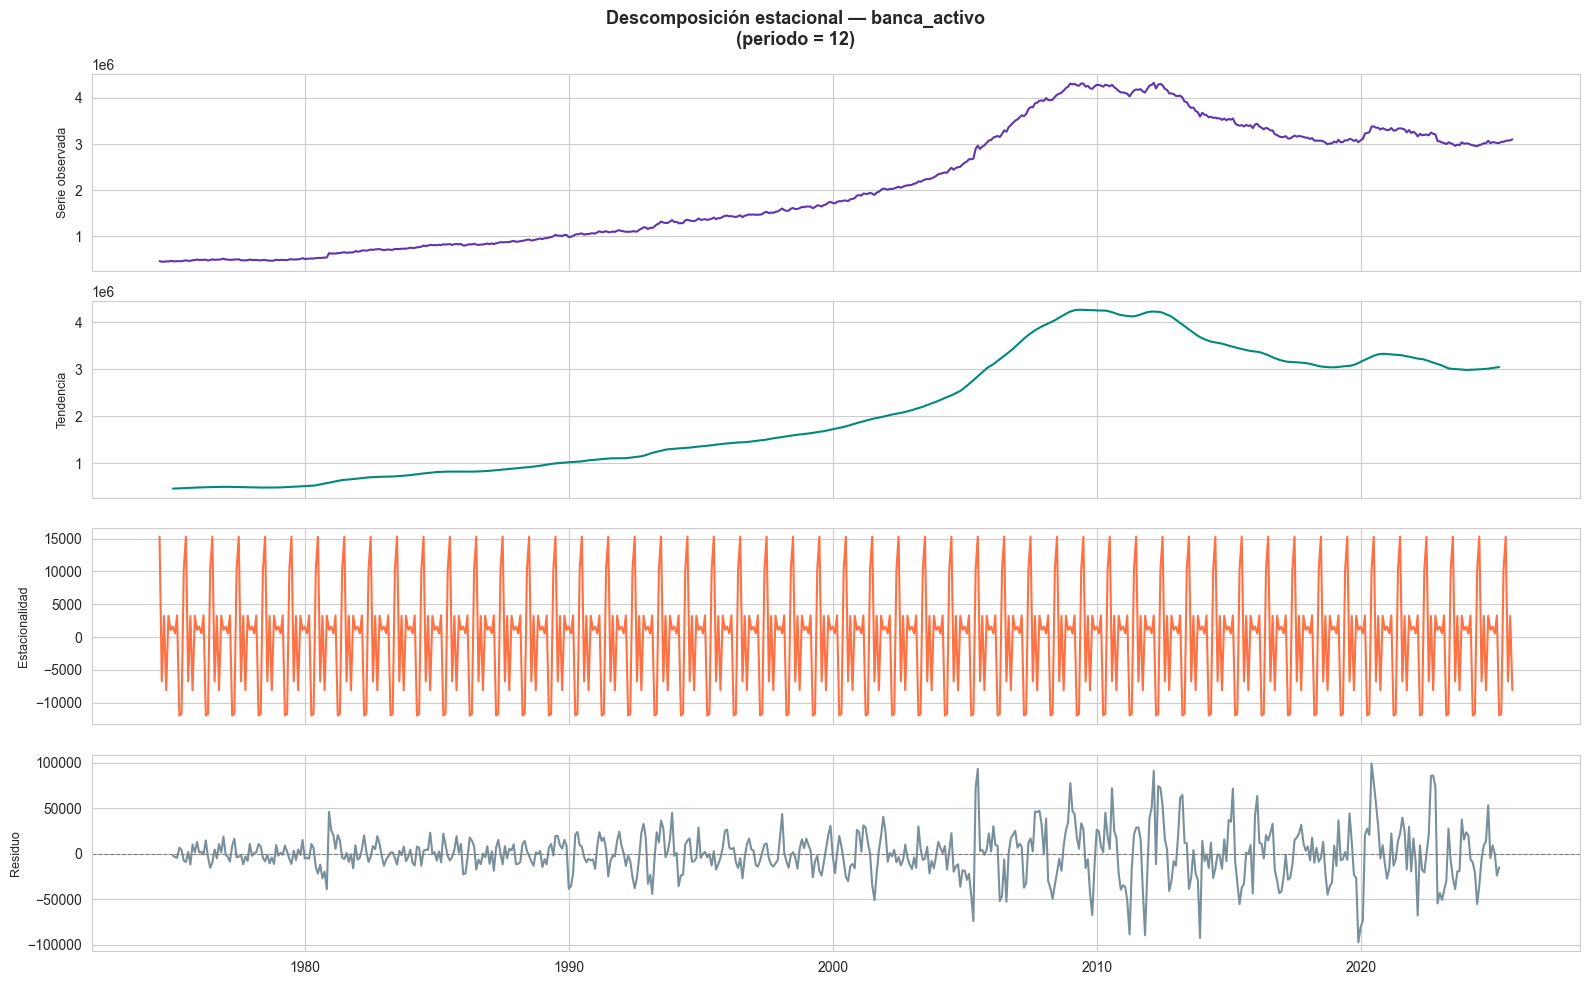

In [15]:
y_descomp = y.dropna()

if len(y_descomp) >= 2 * PERIODO_ESTACIONAL:
    descomp = seasonal_decompose(y_descomp, model='additive', period=PERIODO_ESTACIONAL)

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Descomposición estacional — {NOMBRE}\n(periodo = {PERIODO_ESTACIONAL})',
                 fontsize=13, fontweight='bold')

    componentes = [
        ('Serie observada', descomp.observed, COLOR_PRINCIPAL),
        ('Tendencia', descomp.trend, '#00897B'),
        ('Estacionalidad', descomp.seasonal, '#FF7043'),
        ('Residuo', descomp.resid, '#78909C'),
    ]

    for ax, (titulo, datos, color) in zip(axes, componentes):
        ax.plot(datos.index, datos, color=color, lw=1.5)
        ax.set_ylabel(titulo, fontsize=9)
        if titulo == 'Residuo':
            ax.axhline(0, color='gray', linestyle='--', lw=0.8)

    plt.tight_layout()
    plt.show()
else:
    print(f'Serie demasiado corta para descomposición (necesita ≥ {2*PERIODO_ESTACIONAL} obs, tiene {len(y_descomp)})')

### Análisis:

La descomposición STL con periodo 12 confirma que el `ed_activo_total` no presenta estacionalidad económicamente relevante. La amplitud del componente estacional oscila entre aproximadamente -10.000 y +15.000 millones, lo que sobre una serie que recorre de 450.000 a 4.300.000 millones representa una fracción ínfima del nivel medio. Esta proporción es coherente con la naturaleza del balance bancario y con la ausencia de patrón mensual detectada en el boxplot.

La tendencia captura prácticamente la totalidad de la dinámica de la serie: el crecimiento gradual entre 1975 y 2000, la aceleración explosiva hasta el pico de 2009-2012, y el desapalancamiento posterior hasta el final de la muestra. La suavidad del componente tendencial confirma que el filtro absorbe los movimientos de medio plazo sin distorsiones significativas, incluso en el entorno del pico de 2012 donde el cambio de régimen es más abrupto.

El componente residual presenta un patrón claro de heterocedasticidad que se incrementa de forma sostenida con el tiempo. Entre 1975 y 1995 los residuos permanecen contenidos en una banda de aproximadamente ±20.000 millones, con escasa estructura visible. A partir de 1995 la volatilidad de los residuos crece progresivamente y entre 2005 y 2014 alcanza los valores más extremos de toda la muestra, con picos de aproximadamente ±100.000 millones que reflejan tanto la aceleración crediticia del boom como la volatilidad del proceso de desapalancamiento y reestructuración bancaria. Esta heterocedasticidad creciente, sin ruptura abrupta sino con incremento gradual, es coherente con el aumento del tamaño absoluto del sistema bancario: cuanto mayor es el activo, mayores son en términos absolutos las fluctuaciones residuales que el filtro de tendencia no captura. Para la modelización, este patrón sugiere que la transformación logarítmica o la variación porcentual interanual son preferibles a la primera diferencia en niveles para estabilizar la varianza.

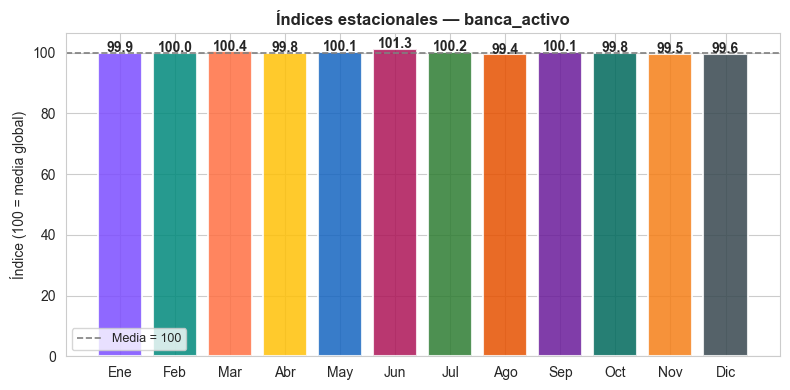

Índices estacionales:
Ene    99.900
Feb   100.000
Mar   100.400
Abr    99.800
May   100.100
Jun   101.300
Jul   100.200
Ago    99.400
Sep   100.100
Oct    99.800
Nov    99.500
Dic    99.600

Periodo con mayor banca_activo: Jun (101.3)
Periodo con menor banca_activo: Ago (99.4)


In [16]:
if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):

    if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
        grupo_idx = y.index.quarter
        etiq_idx = ['T1', 'T2', 'T3', 'T4']
    else:
        grupo_idx = y.index.month
        etiq_idx = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

    media_por_periodo = pd.Series(
        {p: y[grupo_idx == p].mean() for p in sorted(np.unique(grupo_idx))}
    )
    indice_estacional = (media_por_periodo / media_por_periodo.mean() * 100).round(1)
    indice_estacional.index = etiq_idx[:len(indice_estacional)]

    fig, ax = plt.subplots(figsize=(8, 4))
    colores_idx = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
                   '#1565C0', '#AD1457', '#2E7D32', '#E65100',
                   '#6A1B9A', '#00695C', '#F57F17', '#37474F']
    barras = ax.bar(indice_estacional.index, indice_estacional.values,
                    color=colores_idx[:len(indice_estacional)], edgecolor='white',
                    linewidth=1.5, alpha=0.85)
    ax.axhline(100, color='gray', linestyle='--', lw=1.2, label='Media = 100')
    ax.set_title(f'Índices estacionales — {NOMBRE}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Índice (100 = media global)', fontsize=10)
    for b, v in zip(barras, indice_estacional.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Índices estacionales:')
    print(indice_estacional.to_string())
    print(f'\nPeriodo con mayor {NOMBRE}: {indice_estacional.idxmax()} ({indice_estacional.max():.1f})')
    print(f'Periodo con menor {NOMBRE}: {indice_estacional.idxmin()} ({indice_estacional.min():.1f})')

### Análisis:
Los índices estacionales confirman la irrelevancia de la estacionalidad en el `ed_activo_total`. El rango entre el mes de mayor índice (junio, 101,3) y el de menor (agosto, 99,4) es de apenas 1,9 puntos porcentuales, la amplitud más reducida entre las series bancarias y comparable a la del IPRI y el tipo de cambio. El resampleo trimestral no requiere corrección estacional.

---
## 5. Cambios Periodo a Periodo

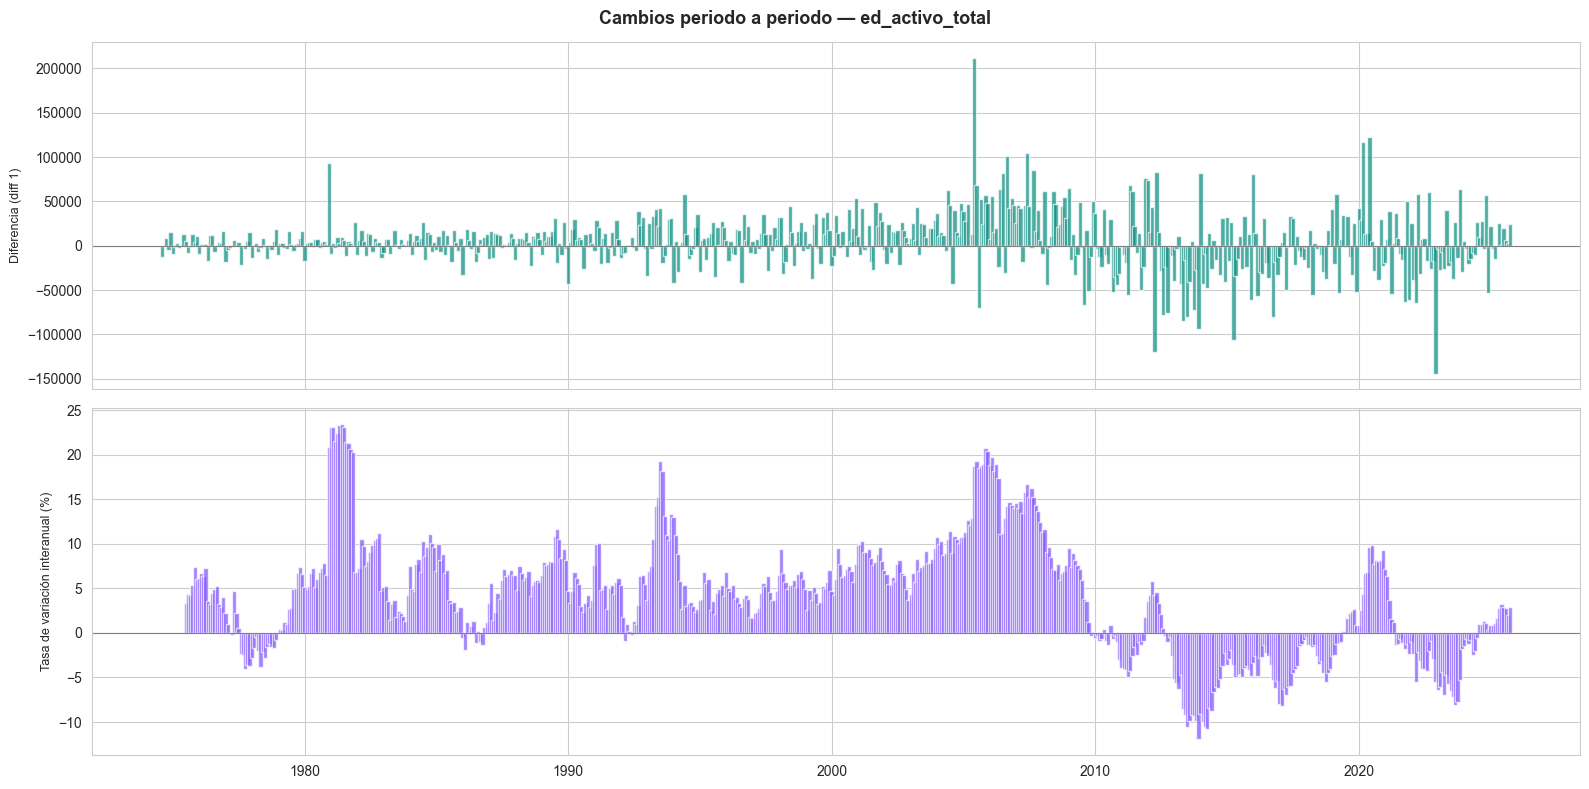

Estadísticas de la variación interanual (%):
count   604.000
mean      4.050
std       6.400
min     -11.960
25%      -0.730
50%       4.330
75%       7.490
max      23.500


In [17]:
diff1 = y.diff(1).dropna()
diff_est = y.diff(PERIODO_ESTACIONAL).dropna()  # se usa en Sección 6 (stationarity test)
pct_yoy = y.pct_change(PERIODO_ESTACIONAL).dropna() * 100
pct_est = pct_yoy  # alias para tests de estacionariedad y ACF/PACF

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Cambios periodo a periodo — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].bar(diff1.index, diff1, color='#00897B', alpha=0.7, width=60)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_ylabel('Diferencia (diff 1)', fontsize=9)

axes[1].bar(pct_yoy.index, pct_yoy, color='#7C4DFF', alpha=0.7, width=60)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_ylabel('Tasa de variación interanual (%)', fontsize=9)

plt.tight_layout()
plt.show()

print('Estadísticas de la variación interanual (%):')
print(pct_yoy.describe().round(2).to_string())

### Análisis:

La diferencia mensual (panel superior) presenta una heterocedasticidad creciente coherente con lo documentado en los residuos STL: la amplitud de los cambios mensuales crece de forma sostenida con el tamaño del balance, desde una banda de aproximadamente ±20.000 millones en 1975-1990 hasta valores extremos de +200.000 y -150.000 millones en el periodo 2005-2012. Esta heterocedasticidad proporcional al nivel refuerza la recomendación de trabajar con variaciones porcentuales en lugar de diferencias absolutas.

La variación interanual (panel inferior) describe tres grandes ciclos de expansión crediticia con intensidades comparables. El primero, en torno a 1980, alcanza un máximo de aproximadamente 23%. El segundo, entre 1988 y 1992, llega a aproximadamente 19%. El tercero y más sostenido, entre 2000 y 2007, mantiene tasas del 10-20% durante casi una década con un máximo de aproximadamente 20% en 2006. La contracción posterior a 2008 es la más larga de la muestra: la variación interanual permanece negativa desde aproximadamente 2010 hasta 2018, con un mínimo de -11,96%, reflejando el desapalancamiento bancario. Un breve repunte positivo en 2020 (avales ICO) da paso a otro tramo negativo en 2021-2023 antes de una recuperación parcial al final de la muestra.

La media de 4,05% y la mediana de 4,33% indican que el crecimiento positivo del activo bancario es el estado predominante de la muestra, con una desviación típica de 6,40% que refleja la amplitud de los ciclos de expansión y contracción. Para la modelización del paro, la variación interanual del `ed_activo_total` es la transformación natural por su sincronización con los ciclos de empleo y su interpretabilidad a través del canal crediticio. Los tests de estacionariedad y correlogramas que se presentan a continuación evaluarán formalmente esta transformación.es la transformación de referencia: estabiliza la varianza, es estacionaria por construcción dado el perfil cíclico observado, y su sincronización con los ciclos de empleo es directamente interpretable a través del canal crediticio.

---
## 6. Estacionariedad y Autocorrelación

In [18]:
def test_estacionariedad(serie, nombre_serie, regression='c'):
    s = serie.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags='auto')
    estacionaria = (adf_p < 0.05) and (kpss_p >= 0.05)
    return {
        'serie': nombre_serie,
        'regression': regression,
        'ADF_stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_H0_rechaza': adf_p < 0.05,
        'KPSS_stat': round(kpss_stat, 4),
        'KPSS_p': round(kpss_p, 4),
        'KPSS_H0_rechaza': kpss_p < 0.05,
        'conclusion': 'ESTACIONARIA' if estacionaria else 'NO ESTACIONARIA',
    }

series_test = [
    (y, f'{VAR_PRINCIPAL} (nivel)', 'ct'),
    (diff1, f'{VAR_PRINCIPAL} (diff 1)', 'c'),
    (diff_est, f'{VAR_PRINCIPAL} (diff {PERIODO_ESTACIONAL})', 'c'),
    (pct_est, f'{VAR_PRINCIPAL} (var interanual %)', 'c'),
]

resultados_est = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test])

print('Tests de estacionariedad:')
print('=' * 85)
print(resultados_est.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_est.iterrows():
    h0_adf = 'rechaza H\u2080' if row['ADF_H0_rechaza'] else 'NO rechaza H\u2080'
    h0_kpss = 'rechaza H\u2080' if row['KPSS_H0_rechaza'] else 'NO rechaza H\u2080'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  (H\u2080 = ra\u00edz unitaria):  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS (H\u2080 = estacionaria):   stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    \u2192 {row['conclusion']}")
    print()

Tests de estacionariedad:
                             serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           ed_activo_total (nivel)         ct    -1.206  0.671           False      0.374   0.010             True NO ESTACIONARIA
          ed_activo_total (diff 1)          c    -3.358  0.013            True      0.423   0.067            False    ESTACIONARIA
         ed_activo_total (diff 12)          c    -2.915  0.044            True      0.367   0.091            False    ESTACIONARIA
ed_activo_total (var interanual %)          c    -2.496  0.117           False      0.851   0.010             True NO ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  ed_activo_total (nivel)  (KPSS regression='ct')
    ADF  (H₀ = raíz unitaria):  stat=-1.206, p=0.6708 (NO rechaza H₀)
    KPSS (H₀ = estacionaria):   stat=0.374, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  ed_activo_total (diff 1)  (KPSS regression

### Análisis:

En niveles, ambos tests convergen en un diagnóstico claro de no estacionariedad: el ADF no rechaza la raíz unitaria (stat=-1,206, p=0,6708) y el KPSS rechaza la estacionariedad (stat=0,374, p=0,0100).

Tanto la primera diferencia como la diferencia de orden 12 producen diagnósticos de estacionariedad, pero con p-valores notablemente más ajustados que en las series analizadas previamente. En diff 1, el ADF rechaza la raíz unitaria (stat=-3,358, p=0,0125) y el KPSS no rechaza la estacionariedad (stat=0,423, p=0,0672), pero ambos p-valores se sitúan lejos de la contundencia habitual: el ADF no está tan próximo a cero como en el IPRI (p=0,0000) o el PIB (p=0,0000), y el KPSS roza el umbral de rechazo al 5% con un p-valor de 0,0672. En diff 12, el patrón se repite con márgenes aún más estrechos: el ADF apenas rechaza (stat=-2,915, p=0,0436) y el KPSS tampoco rechaza la estacionariedad pero con p=0,0914, próximo al límite.

La fragilidad de los diagnósticos en diferencias y el fracaso de la variación interanual son coherentes con la heterocedasticidad creciente documentada en los residuos STL: la varianza no constante reduce la potencia de los tests y deja los p-valores en zona marginal. Entre las transformaciones evaluadas, la primera diferencia es la única utilizable de forma directa para la modelización del paro a partir de `ed_activo_total`, con diff 12 como alternativa equivalente para captar la componente interanual. La variación interanual porcentual queda descartada por el propio diagnóstico, y la marginalidad de los p-valores en diff 1 y diff 12 queda documentada como limitación a tener presente en la evaluación de residuos en la fase de modelización.

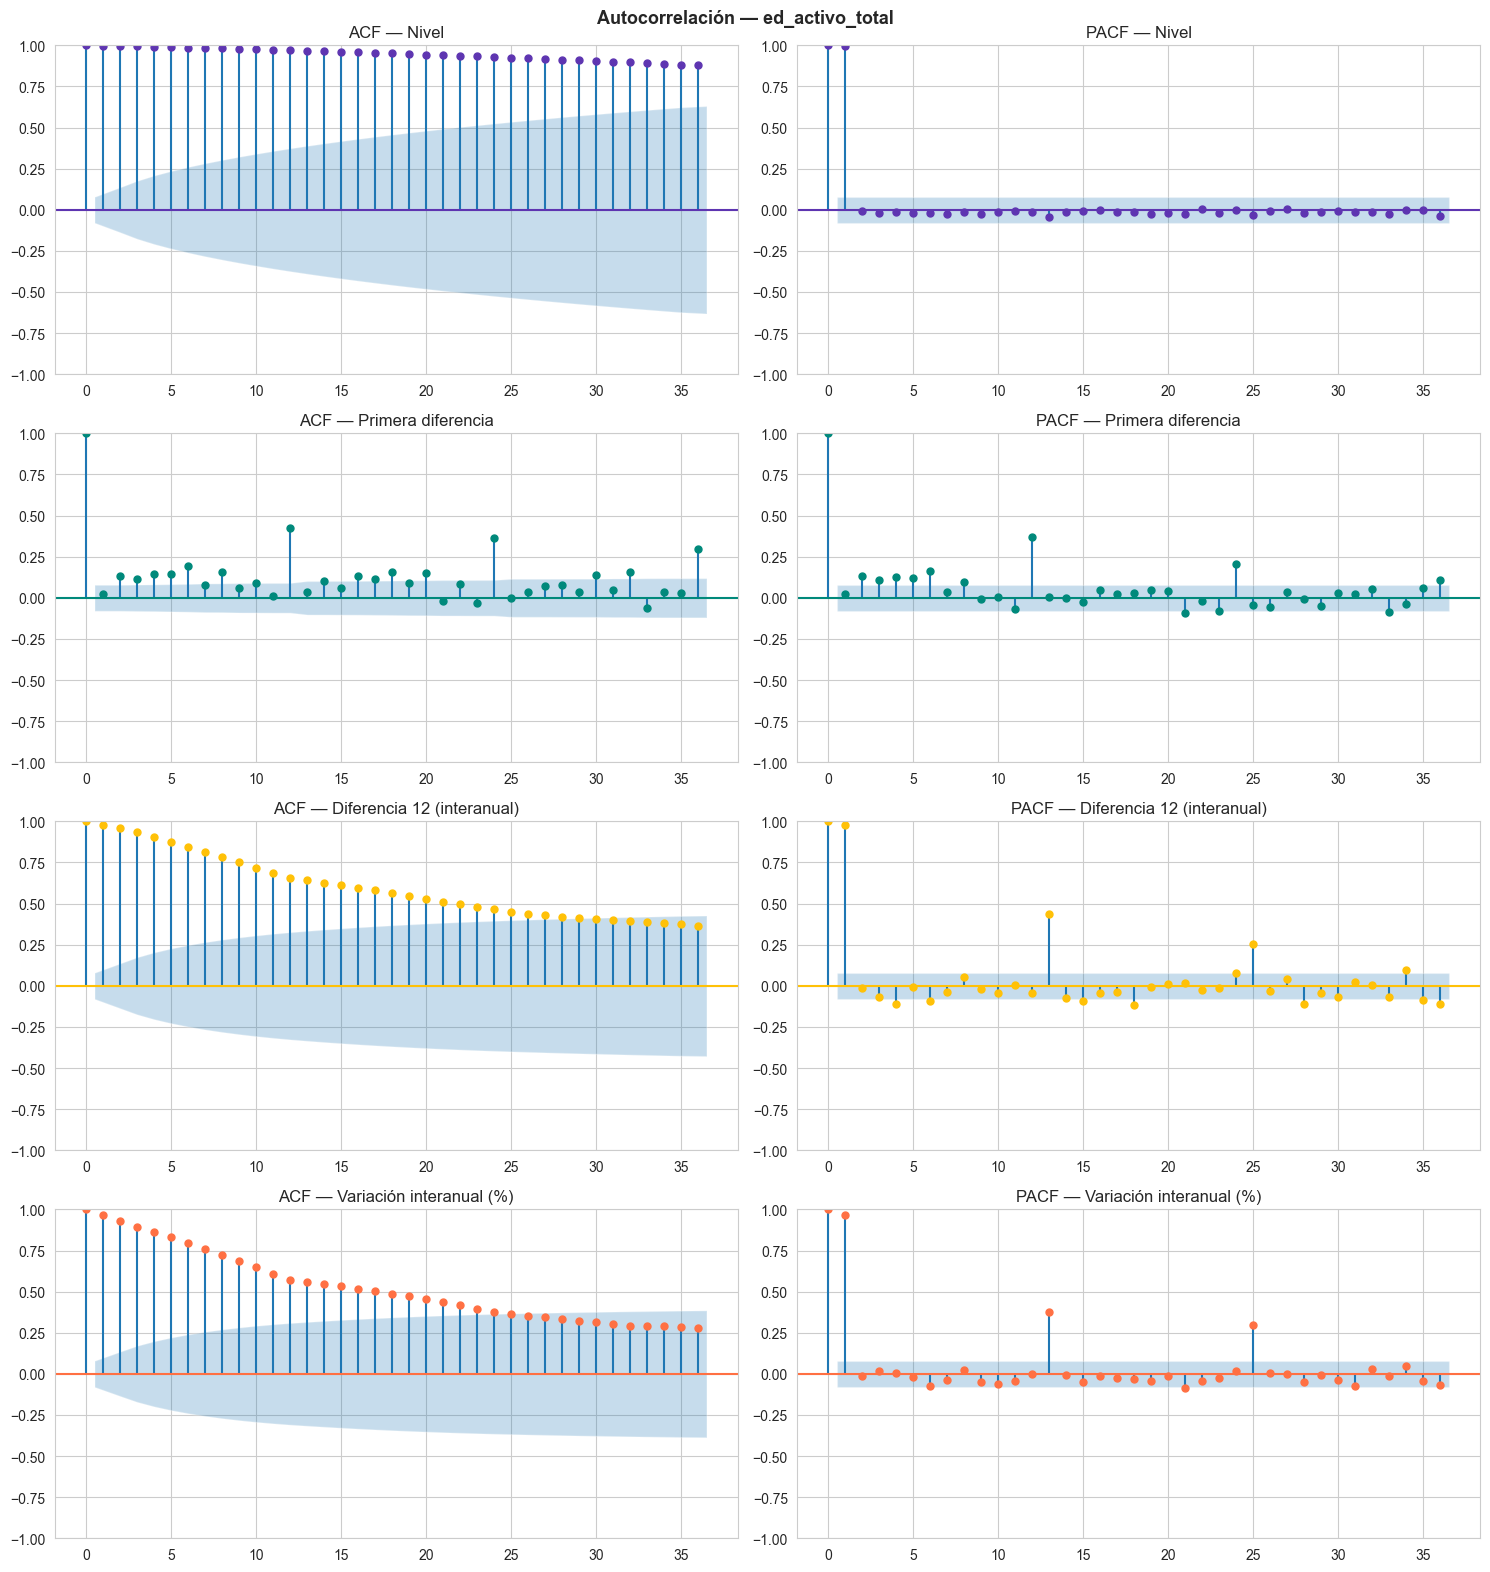

In [19]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
fig.suptitle(f'Autocorrelación — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel')
plot_pacf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel', method='ywm')
plot_acf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 0], color='#00897B',
         title='ACF — Primera diferencia')
plot_pacf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 1], color='#00897B',
          title='PACF — Primera diferencia', method='ywm')
plot_acf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 0], color='#FFC107',
         title=f'ACF — Diferencia {PERIODO_ESTACIONAL} (interanual)')
plot_pacf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 1], color='#FFC107',
          title=f'PACF — Diferencia {PERIODO_ESTACIONAL} (interanual)', method='ywm')
plot_acf(pct_est.dropna(), lags=LAGS_ACF, ax=axes[3, 0], color='#FF7043',
         title='ACF — Variación interanual (%)')
plot_pacf(pct_est.dropna(), lags=LAGS_ACF, ax=axes[3, 1], color='#FF7043',
          title='PACF — Variación interanual (%)', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

En niveles, el patrón habitual de no estacionariedad: ACF con decaimiento extremadamente lento desde valores próximos a 0,90 y PACF con pico único en el lag 1, coherente con el diagnóstico formal de raíz unitaria.

Tras la primera diferencia, la mayoría de los lags caen dentro de la banda de significancia, pero la estacionalidad mensual residual queda visible en ambos correlogramas. La ACF presenta picos en los lags 12 (aproximadamente +0,45), 24 (aproximadamente +0,35) y 36 (aproximadamente +0,30), y la PACF reproduce el patrón con un pico en el lag 12 (aproximadamente +0,38) y otro menor en el lag 24 (aproximadamente +0,20). La estructura no estacional aparece amortiguada, con un pico leve en el lag 1 de la PACF (aproximadamente +0,15) sin continuidad clara en los lags siguientes. El patrón es similar al documentado para el `pib_pm`, donde la diff 1 retenía estacionalidad de periodo 4; aquí el periodo es 12 porque la serie opera en frecuencia mensual.

La diff 12 produce el resultado más problemático. La ACF decae de forma extremadamente lenta desde valores próximos a 0,95, manteniéndose significativa a lo largo de todos los lags representados, con un perfil visualmente similar al de la serie en niveles. La PACF muestra un pico dominante en el lag 1 (aproximadamente +0,95) y picos secundarios en los lags 13 (aproximadamente +0,45) y 25 (aproximadamente +0,25). Este patrón indica que la variación interanual del `ed_activo_total` retiene una persistencia muy elevada, coherente con la naturaleza de los ciclos crediticios: las fases de expansión y contracción del crédito duran 5-10 años cada una, lo que genera autocorrelación positiva fuerte que se propaga a través de múltiples lags. La persistencia explica los p-valores marginales del ADF/KPSS sobre la diff 12 y matiza el diagnóstico de estacionariedad: pese a cruzar el umbral formal, la transformación se comporta en la práctica casi como una serie no estacionaria.

La variación interanual porcentual reproduce el mismo patrón con magnitud equivalente: ACF con decaimiento lento desde valores próximos a 0,95 y PACF con pico dominante en el lag 1 (aproximadamente +0,95) más picos secundarios en los lags 13 (aproximadamente +0,38) y 25 (aproximadamente +0,30). El correlograma confirma visualmente el resultado del test, donde esta transformación salió como no estacionaria: normalizar por el nivel no rompe la persistencia intrínseca del ciclo crediticio.

Para la modelización, la persistencia compartida por diff 12 y variación interanual implica que un modelo ARIMA con diferenciación estacional requerirá componentes AR de orden alto para capturar la inercia crediticia. La primera diferencia, con su estacionalidad residual de periodo 12, es la única transformación de las evaluadas que combina estacionariedad formal con un perfil ACF/PACF tratable mediante términos SARIMA convencionales.

### 6.1 Transformación logarítmica

La heterocedasticidad proporcional al nivel documentada en los residuos STL (Seasonal-Trend decomposition using Loess) y en la primera diferencia (varianza creciente con el tamaño del balance) motiva probar la transformación logarítmica.

La transformación logarítmica se aplica únicamente a las series de balance bancario (activo y pasivo), donde la heterocedasticidad es proporcional al nivel y no existe normalización natural por base. En los índices (IPC, IPRI, IPI) la variación interanual porcentual cumple una función análoga al ser equivalente, para variaciones pequeñas, a `diff(log(y), 12)`. Para las series con clusters de volatilidad condicional (tipo de cambio, primera diferencia de la tasa de paro) la log no procede metodológicamente, por lo que la heterocedasticidad queda documentada sin tratamiento en la fase de transformación.

Se evalúan dos transformaciones combinadas:
- `Δ1 log(y)` — crecimiento mensual continuo (aproxima la tasa de variación mensual)
- `Δ12 log(y)` — crecimiento interanual continuo (aproxima la tasa de variación interanual)

In [20]:
log_y = np.log(y[y > 0]).dropna()
log_diff1 = log_y.diff(1).dropna()
log_diff_est = log_y.diff(PERIODO_ESTACIONAL).dropna()

series_test_log = [
    (log_y, f'log({VAR_PRINCIPAL})', 'ct'),
    (log_diff1, f'Δ1 log({VAR_PRINCIPAL})', 'c'),
    (log_diff_est, f'Δ{PERIODO_ESTACIONAL} log({VAR_PRINCIPAL})', 'c'),
]

resultados_log = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test_log])

print('Tests de estacionariedad — transformación logarítmica:')
print('=' * 85)
print(resultados_log.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_log.iterrows():
    h0_adf = 'rechaza H₀' if row['ADF_H0_rechaza'] else 'NO rechaza H₀'
    h0_kpss = 'rechaza H₀' if row['KPSS_H0_rechaza'] else 'NO rechaza H₀'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    → {row['conclusion']}")
    print()

Tests de estacionariedad — transformación logarítmica:
                   serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
    log(ed_activo_total)         ct    -1.680  0.442           False      0.623   0.010             True NO ESTACIONARIA
 Δ1 log(ed_activo_total)          c    -3.779  0.003            True      1.380   0.010             True NO ESTACIONARIA
Δ12 log(ed_activo_total)          c    -2.483  0.120           False      0.888   0.010             True NO ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  log(ed_activo_total)  (KPSS regression='ct')
    ADF  stat=-1.680, p=0.4415 (NO rechaza H₀)
    KPSS stat=0.623, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  Δ1 log(ed_activo_total)  (KPSS regression='c')
    ADF  stat=-3.779, p=0.0031 (rechaza H₀)
    KPSS stat=1.380, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  Δ12 log(ed_activo_total)  (KPSS regression='c')
    ADF  stat=-2.483, p=0.

### Análisis:

La transformación logarítmica no produce estacionariedad en ninguna de las tres especificaciones testadas, resultado opuesto al esperado tras documentar la heterocedasticidad proporcional al nivel en los residuos STL. En log-niveles, ambos tests convergen en no estacionariedad: el ADF no rechaza la raíz unitaria (stat=-1,680, p=0,4415) y el KPSS rechaza la estacionariedad (stat=0,623, p=0,0100), patrón habitual de serie tendencial.

La Δ1 del logaritmo produce la contradicción directa que la convergencia ADF/KPSS reserva para casos de outliers o cambio estructural: el ADF rechaza contundentemente la raíz unitaria (stat=-3,779, p=0,0031) pero el KPSS también rechaza la estacionariedad con fuerza (stat=1,380, p=0,0100). En Δ12 del logaritmo los tests vuelven a converger en no estacionariedad: ADF no rechaza (stat=-2,483, p=0,1196) y KPSS rechaza (stat=0,888, p=0,0100).

La log corrige la heterocedasticidad proporcional al nivel, según anticipaba el diagnóstico de los residuos STL, pero al hacerlo deja al descubierto una característica del proceso generador que la escala absoluta enmascaraba: un cambio estructural en la tasa de crecimiento del activo bancario, compatible con el quiebre del ciclo crediticio en la crisis financiera de 2008. En diferencias absolutas (sin log), las oscilaciones del periodo de bajo crecimiento ocurren sobre una base mucho mayor en EUR, lo que compensa parcialmente la caída en la tasa de crecimiento y permite que la diff 1 cruce el umbral de estacionariedad con p-valores marginales. En la Δ1 del logaritmo ese efecto compensatorio desaparece y el quiebre en la media de la tasa de crecimiento se vuelve estadísticamente detectable mediante el KPSS.

La consecuencia operativa es directa: la transformación logarítmica no aporta una alternativa mejor que la primera diferencia para la modelización del paro a partir del `ed_activo_total`. La diff 1 sin log se mantiene como transformación de trabajo, con su marginalidad documentada. El cambio estructural de 2008 queda documentado como hallazgo del EDA y como vía complementaria a explorar en la fase de modelización mediante dummy de régimen o modelos de cambio de régimen si los residuos del modelo final lo justifican.

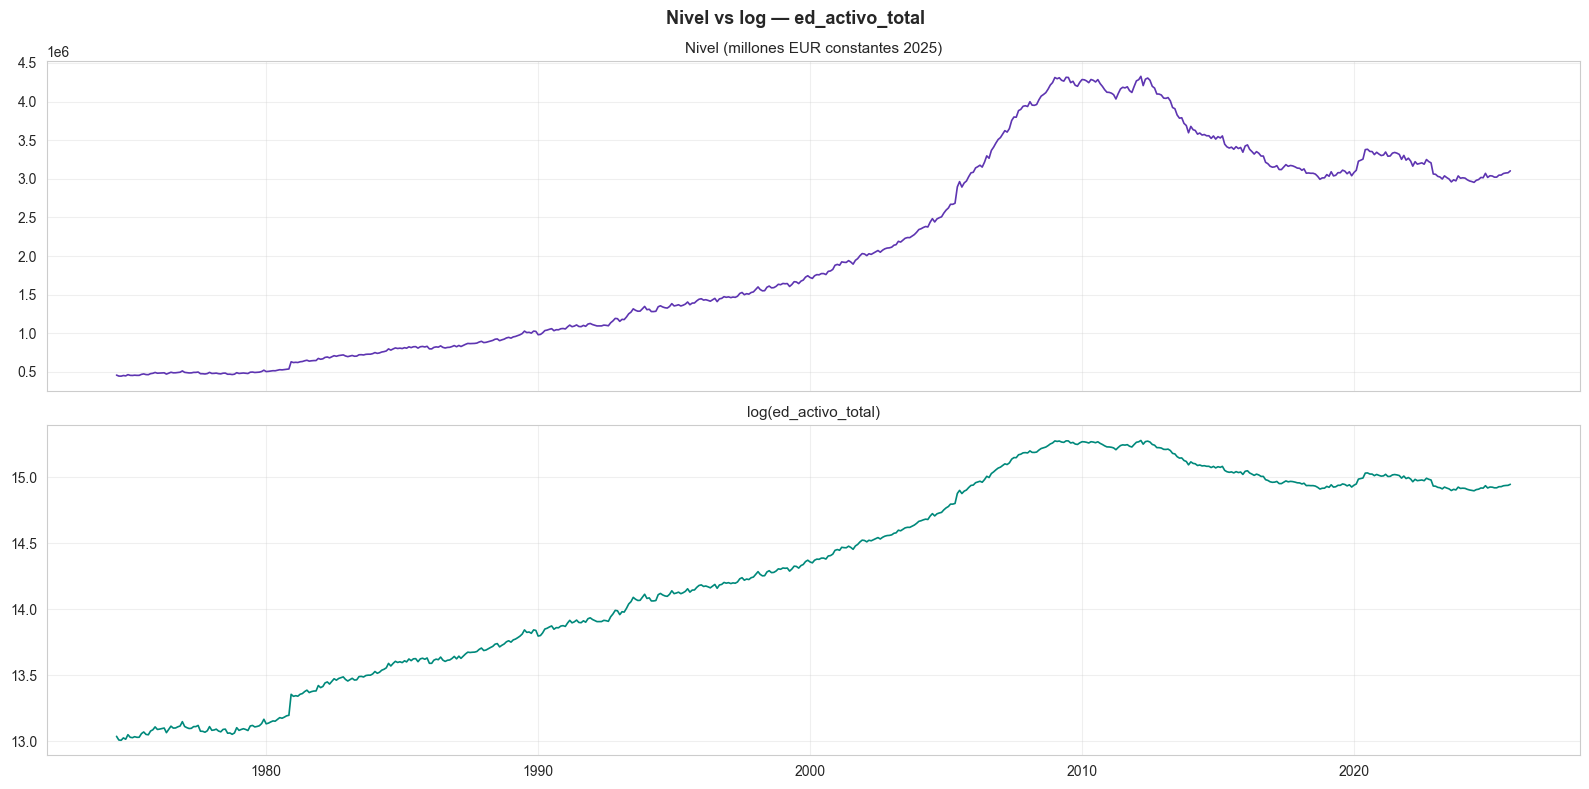

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Nivel vs log — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].plot(y.index, y, color=COLOR_PRINCIPAL, lw=1.2)
axes[0].set_title(f'Nivel ({UNIDADES})', fontsize=11)
axes[0].grid(alpha=0.3)

axes[1].plot(log_y.index, log_y, color='#00897B', lw=1.2)
axes[1].set_title(f'log({VAR_PRINCIPAL})', fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis:

La transformación logarítmica revela un cambio de régimen en la tasa de crecimiento del activo bancario en torno a 2008 que la escala absoluta camufla parcialmente. En niveles, la serie progresa desde aproximadamente 0,5 billones de EUR en 1974 hasta un pico próximo a 4,3 billones en 2008-2012, seguido de una contracción hasta valores cercanos a 3 billones al final de la muestra, forma habitual de un proceso de crecimiento aproximadamente exponencial seguido de saturación y retroceso.

En escala logarítmica, la dinámica se reorganiza: la fase de crecimiento sostenido pre-2008 aparece como una pendiente aproximadamente constante entre 13,0 y 15,3 en logaritmos, y la fase posterior a 2008-2010 se aplana notablemente, con el log estabilizándose en torno a 15,0 durante quince años. Este aplanamiento es la representación gráfica directa del cambio estructural en la tasa de crecimiento que los tests sobre Δ1 log detectaron mediante la contradicción ADF/KPSS. En escala absoluta el quiebre queda parcialmente camuflado por el efecto compensatorio del crecimiento previo, mientras que en escala logarítmica se vuelve visualmente evidente.

Una característica adicional visible en ambos paneles es una discontinuidad en torno a 1981, con un salto en el nivel que rompe brevemente la continuidad de la serie antes de retomar la trayectoria de crecimiento sostenido. La discontinuidad no se origina en ningún proceso de empalme o transformación aplicado en este proyecto, dado que la serie procede íntegramente del Boletín Estadístico del Banco de España. Su origen probable está en algún cambio metodológico o de perímetro de entidades aplicado por la fuente en ese periodo, pero la atribución concreta no se ha verificado en este trabajo. El punto constituye un tramo de atención para la modelización sobre la muestra completa, sin afectar a la dinámica de las fases posteriores.

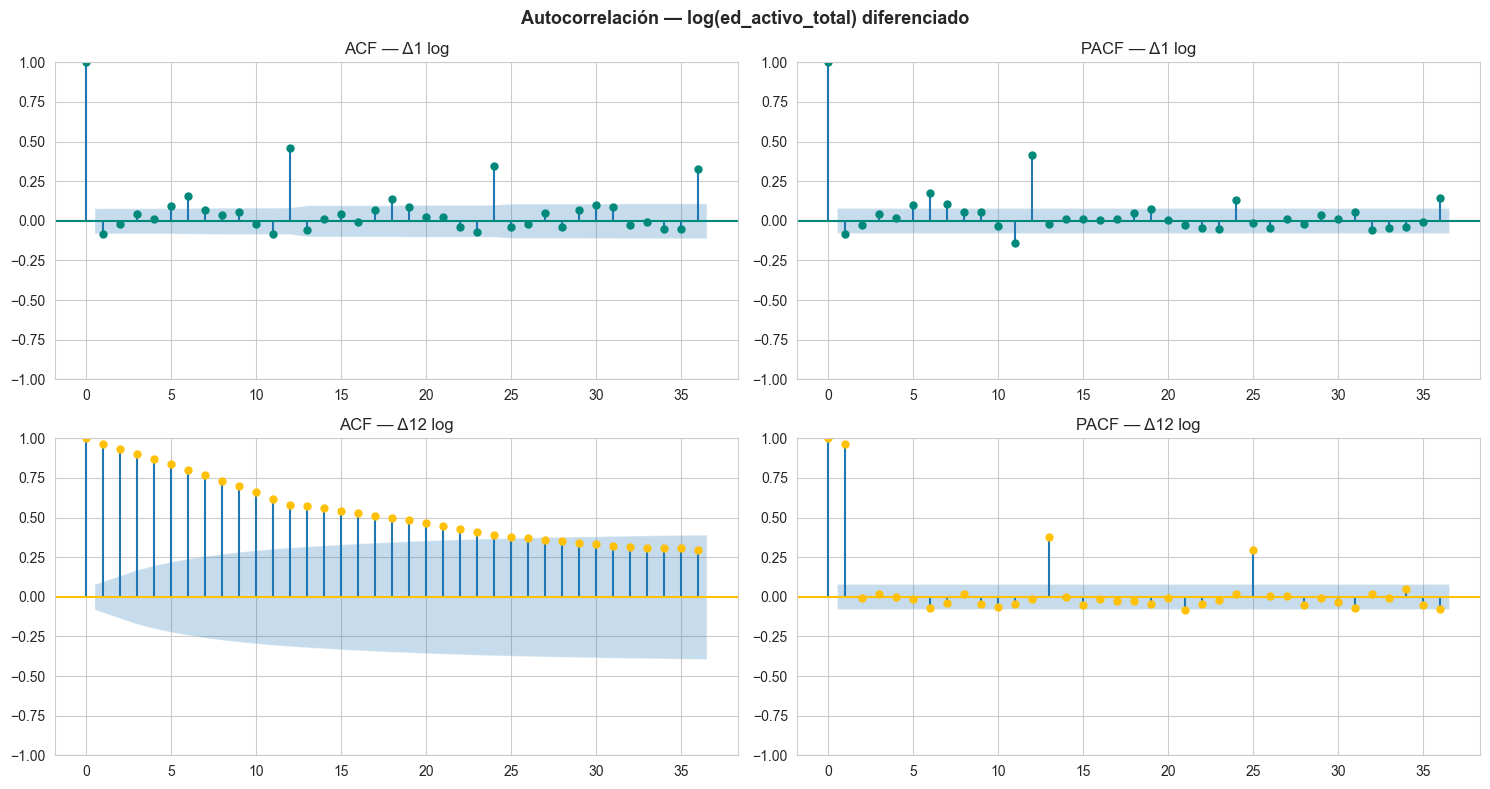

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f'Autocorrelación — log({VAR_PRINCIPAL}) diferenciado', fontsize=13, fontweight='bold')

plot_acf(log_diff1, lags=LAGS_ACF, ax=axes[0, 0], color='#00897B',
         title='ACF — Δ1 log')
plot_pacf(log_diff1, lags=LAGS_ACF, ax=axes[0, 1], color='#00897B',
          title='PACF — Δ1 log', method='ywm')
plot_acf(log_diff_est, lags=LAGS_ACF, ax=axes[1, 0], color='#FFC107',
         title=f'ACF — Δ{PERIODO_ESTACIONAL} log')
plot_pacf(log_diff_est, lags=LAGS_ACF, ax=axes[1, 1], color='#FFC107',
          title=f'PACF — Δ{PERIODO_ESTACIONAL} log', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

Los correlogramas de las series logarítmicas diferenciadas confirman que la persistencia detectada en las transformaciones sin log no es un artefacto de la heterocedasticidad. En la Δ1 del logaritmo, la ACF presenta el mismo patrón de estacionalidad mensual residual que la diff 1 sin log, con picos en los lags 12 (aproximadamente +0,45), 24 (aproximadamente +0,35) y 36 (aproximadamente +0,30). La PACF reproduce el rasgo dominante en el lag 12 (aproximadamente +0,40), con el resto de lags en su mayoría dentro de la banda de significancia.

En la Δ12 del logaritmo, la ACF mantiene un decaimiento lento desde valores próximos a 0,95, prácticamente idéntico al de la diff 12 sin log. La PACF muestra un pico dominante en el lag 1 (aproximadamente +0,95) y picos secundarios en los lags 13 (aproximadamente +0,38) y 25 (aproximadamente +0,30).

La equivalencia entre los correlogramas con y sin transformación logarítmica demuestra que la persistencia es una propiedad estructural del proceso generador, no una consecuencia de la varianza no constante. La log estabiliza la varianza pero no altera la dependencia temporal. Para la modelización, esto confirma que los componentes AR de orden alto que requerirá un modelo ARIMA estacional no son evitables mediante transformación previa de la serie.

### 6.2 Validación a frecuencia trimestral

El bloque previo de tests caracteriza la serie a su frecuencia original, donde la información es más rica. La modelización del paro, sin embargo, opera a frecuencia trimestral (target EPA), por lo que las transformaciones operativas deben validarse a esa misma frecuencia.

Este bloque verifica que las conclusiones sobre estacionariedad se trasladan correctamente a la serie resampleada (por valor de cierre trimestral, coherente con la naturaleza de la variable), sobre la que opera el modelo. Se evalúan las mismas cuatro transformaciones que a frecuencia original:
- nivel trimestral
- `Δ1` trimestral (cambio intertrimestral)
- `Δ4` trimestral (cambio interanual)
- variación interanual porcentual trimestral

In [23]:
# Resampleo a frecuencia trimestral
LAGS_ACF_Q = 16
METODO_Q = 'valor de cierre'
y_q = df[VAR_PRINCIPAL].resample('QS').last().dropna()

diff1_q = y_q.diff(1).dropna()
diff4_q = y_q.diff(4).dropna()
pct_q = ((y_q / y_q.shift(4) - 1) * 100).dropna()

series_test_q = [
    (y_q, f'{VAR_PRINCIPAL} trimestral (nivel)', 'ct'),
    (diff1_q, f'{VAR_PRINCIPAL} trimestral (Δ1)', 'c'),
    (diff4_q, f'{VAR_PRINCIPAL} trimestral (Δ4)', 'c'),
    (pct_q, f'{VAR_PRINCIPAL} trimestral (var interanual %)', 'c'),
]

resultados_q = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test_q])

print(f'Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: {METODO_Q}):')
print('=' * 85)
print(resultados_q.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_q.iterrows():
    h0_adf = 'rechaza H₀' if row['ADF_H0_rechaza'] else 'NO rechaza H₀'
    h0_kpss = 'rechaza H₀' if row['KPSS_H0_rechaza'] else 'NO rechaza H₀'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    → {row['conclusion']}")
    print()

Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: valor de cierre):
                                        serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           ed_activo_total trimestral (nivel)         ct    -1.353  0.605           False      0.224   0.010             True NO ESTACIONARIA
              ed_activo_total trimestral (Δ1)          c    -2.612  0.090           False      0.259   0.100            False NO ESTACIONARIA
              ed_activo_total trimestral (Δ4)          c    -2.353  0.155           False      0.236   0.100            False NO ESTACIONARIA
ed_activo_total trimestral (var interanual %)          c    -2.532  0.108           False      0.568   0.026             True NO ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  ed_activo_total trimestral (nivel)  (KPSS regression='ct')
    ADF  stat=-1.353, p=0.6048 (NO rechaza H₀)
    KPSS stat=0.224, p=0.0100 (rechaz

### Análisis:

El diagnóstico de estacionariedad a frecuencia trimestral difiere del obtenido a frecuencia mensual en un aspecto sustantivo: las cuatro transformaciones evaluadas resultan no estacionarias, frente a las dos diagnosis de estacionariedad marginal que produjo el bloque mensual. Las cuatro convergen en no estacionariedad, pero por patrones diagnósticos distintos.

El nivel trimestral reproduce el patrón habitual de serie tendencial: ADF no rechaza la raíz unitaria (stat=-1,353, p=0,6048) y KPSS rechaza la estacionariedad (stat=0,224, p=0,0100). Ambos tests convergen sin ambigüedad.

La Δ1 trimestral y la Δ4 trimestral caen ambas en la zona ambigua de la convergencia ADF/KPSS: ninguno de los dos tests rechaza su hipótesis nula. Para la Δ1, ADF stat=-2,612, p=0,0904 (no rechaza) y KPSS stat=0,259, p=0,1000 (no rechaza). Para la Δ4, ADF stat=-2,353, p=0,1555 (no rechaza) y KPSS stat=0,236, p=0,1000 (no rechaza). En ausencia de evidencia concluyente en ninguna dirección, el criterio conservador clasifica ambas como no estacionarias. La variación interanual porcentual reproduce el diagnóstico del bloque mensual: ambos tests convergen en no estacionariedad (ADF p=0,1078, KPSS p=0,0264).

El cambio de diagnóstico entre frecuencias tiene explicación metodológica directa. El resampleo por valor de cierre, elegido por coherencia con la naturaleza contable del activo bancario como stock de fin de periodo, conserva la varianza y la persistencia originales sin el efecto suavizador de un promedio trimestral. A esto se suma la reducción muestral de 616 observaciones mensuales a 206 trimestrales. La combinación de ambos factores reduce la potencia estadística de los tests sobre Δ1 y Δ4, que en frecuencia mensual cruzaban el umbral con p-valores ajustados, hasta situarlos en la zona ambigua. Las propiedades fundamentales del proceso generador no han cambiado al resamplear; lo que ha cambiado es la capacidad de los tests para distinguir estacionariedad de no estacionariedad con menos observaciones y sin promedio amortiguador.

La implicación para la búsqueda de estacionariedad es que, a la frecuencia operativa del modelo, ninguna de las cuatro transformaciones evaluadas en este bloque produce un diagnóstico limpio. El `ed_activo_total` se comporta como serie altamente persistente, y la transformación que más se aproxima a la estacionariedad es la primera diferencia, que queda como candidata de trabajo con el diagnóstico no concluyente documentado. La elección final de la forma con que la serie entrará en cada modelo se resuelve en la fase de feature engineering.

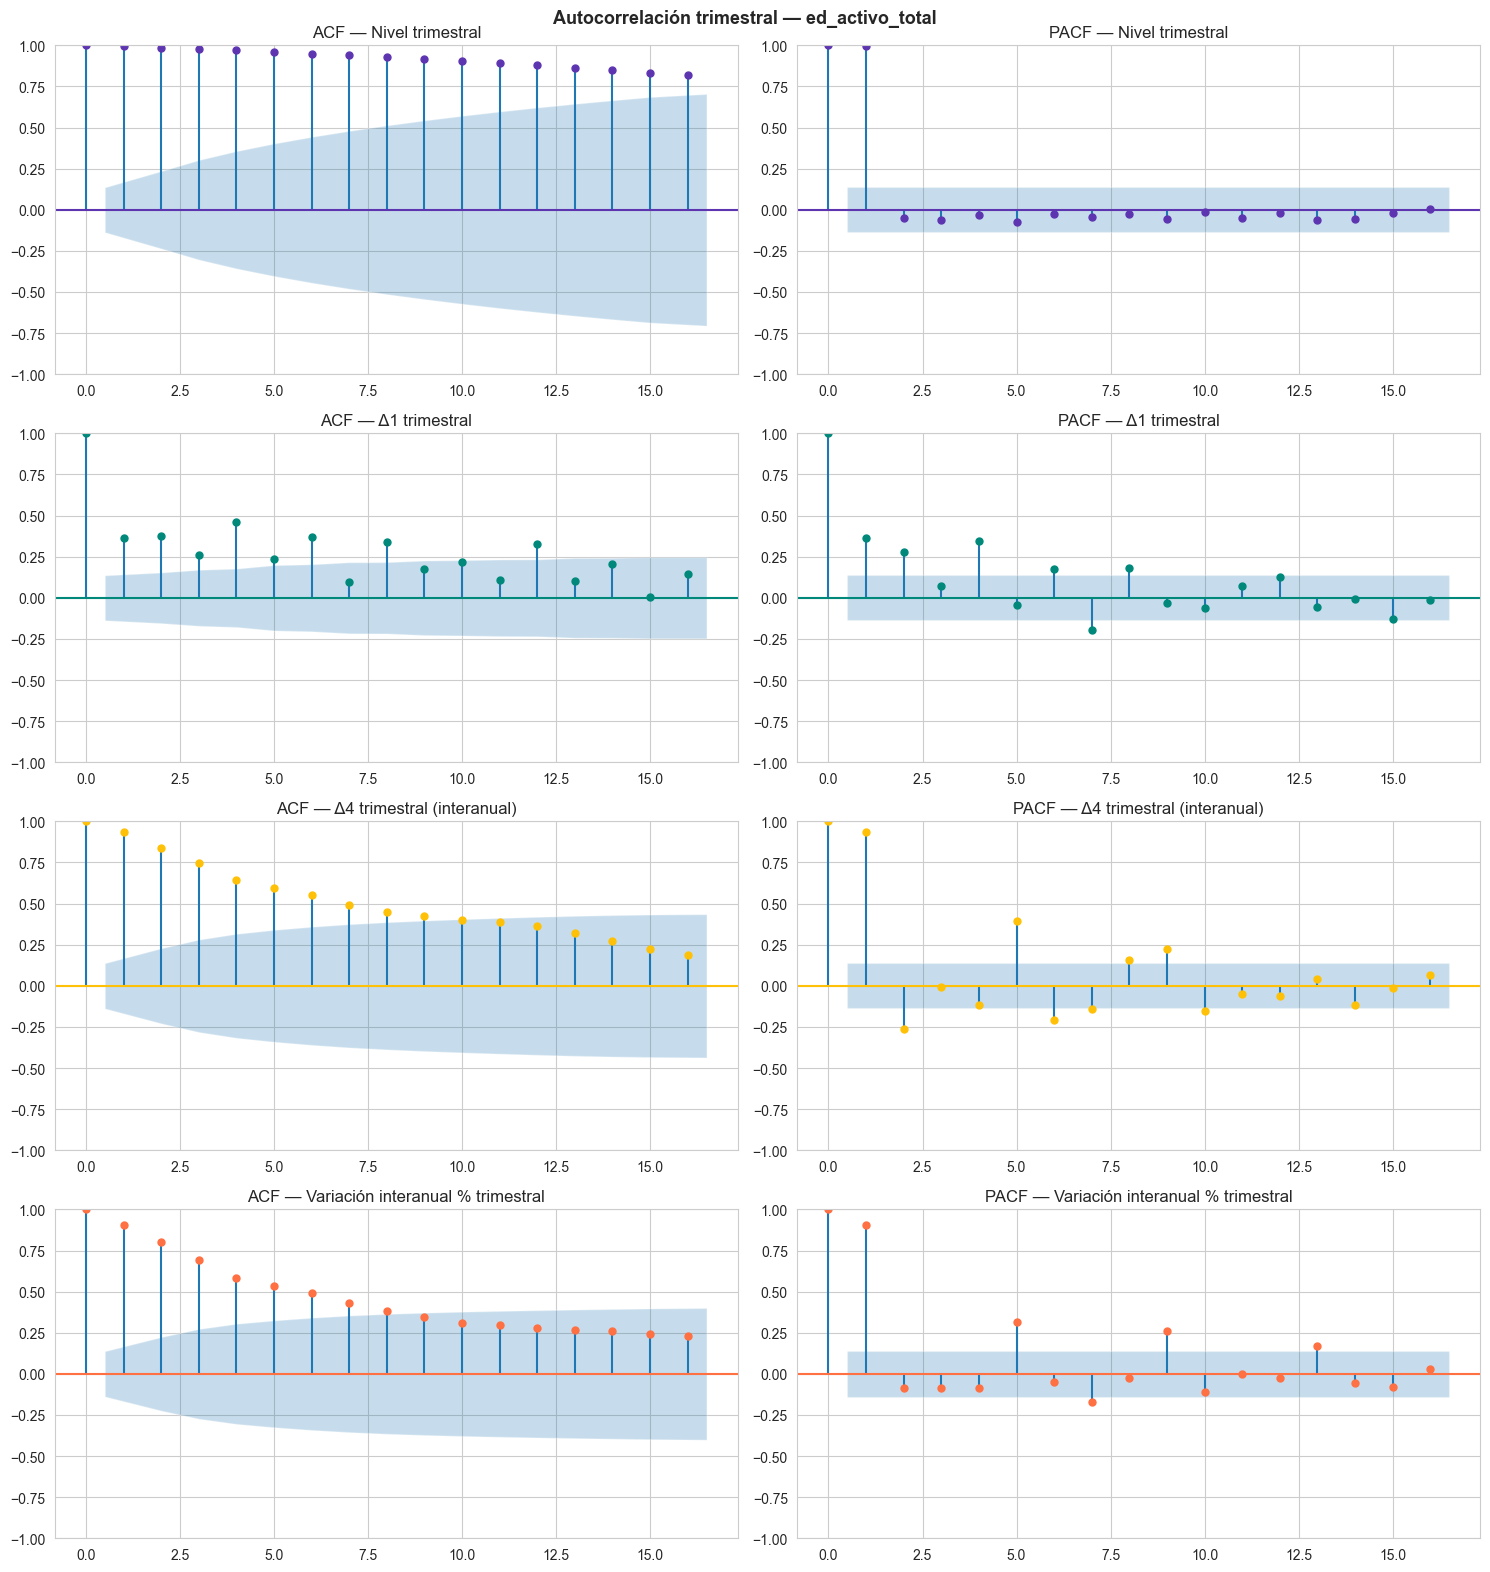

In [24]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
fig.suptitle(f'Autocorrelación trimestral — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel trimestral')
plot_pacf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel trimestral', method='ywm')
plot_acf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 0], color='#00897B',
         title='ACF — Δ1 trimestral')
plot_pacf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 1], color='#00897B',
          title='PACF — Δ1 trimestral', method='ywm')
plot_acf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 0], color='#FFC107',
         title='ACF — Δ4 trimestral (interanual)')
plot_pacf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 1], color='#FFC107',
          title='PACF — Δ4 trimestral (interanual)', method='ywm')
plot_acf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 0], color='#FF7043',
         title='ACF — Variación interanual % trimestral')
plot_pacf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 1], color='#FF7043',
          title='PACF — Variación interanual % trimestral', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

Los correlogramas trimestrales son coherentes con el diagnóstico no concluyente de los tests y confirman la persistencia del activo bancario a la frecuencia operativa del modelo. El nivel reproduce el patrón de raíz unitaria, con ACF de decaimiento lento desde valores próximos a uno y PACF con pico único en el lag 1 (aproximadamente +0,95), sin estructura adicional relevante a partir del lag 2.

La Δ1 trimestral no logra una estructura limpia. La ACF mantiene varios lags por encima de la banda de significancia, con un pico destacado en el lag 4 (aproximadamente +0,47) que señala estacionalidad anual residual no eliminada por la diferencia simple, acompañado de valores significativos en los lags 1, 2 y 6. La PACF reproduce ese patrón con picos en los lags 1, 2 y 4 (todos entre +0,27 y +0,37), confirmando que la primera diferencia deja estructura tanto de corto plazo como estacional. Es el correlograma esperable de una serie cuya Δ1 cae en zona ambigua: la diferencia reduce la persistencia pero no la elimina.

La Δ4 trimestral mantiene una ACF de decaimiento lento desde valores próximos a 0,95, perfil casi indistinguible del nivel, con PACF dominada por un pico en el lag 1 (aproximadamente +0,94) y un secundario en el lag 5 (aproximadamente +0,40). La variación interanual porcentual reproduce el mismo comportamiento: ACF de decaimiento lento desde aproximadamente 0,91 y PACF con pico dominante en el lag 1 (aproximadamente +0,91). La equivalencia entre Δ4 y variación interanual a frecuencia trimestral confirma que la transformación interanual, en cualquiera de sus dos formas, no rompe la persistencia del ciclo crediticio.

La lectura conjunta indica que ninguna de las transformaciones evaluadas produce un corte limpio en ACF o PACF. La Δ1 es la que más reduce la persistencia, aunque mantiene autocorrelación de corto plazo y un residuo estacional de periodo 4. La Δ4 y la variación interanual conservan el decaimiento lento característico de la no estacionariedad. El correlograma confirma así el diagnóstico de los tests: la serie es persistente en todas sus formas y ninguna transformación la lleva a un comportamiento claramente estacionario.

In [25]:
# Estacionalidad trimestral reconstruida desde y_q
if len(y_q) >= 8:
    colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107']
    df_box_q = pd.DataFrame({
        'trimestre': y_q.index.quarter.map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}),
        'valor': y_q.values,
        'fecha': y_q.index.strftime('%Y-%m-%d'),
    })
    df_box_q['trimestre'] = pd.Categorical(df_box_q['trimestre'],
                                            categories=['Q1', 'Q2', 'Q3', 'Q4'], ordered=True)
    fig = px.box(
        df_box_q, x='trimestre', y='valor', color='trimestre',
        hover_data=['fecha'],
        title=f'Estacionalidad trimestral — {VAR_PRINCIPAL}',
        labels={'valor': UNIDADES, 'trimestre': 'Trimestre'},
        color_discrete_sequence=colores_bp,
    )
    fig.update_layout(showlegend=False, height=420)
    fig.show()

    medias_q = y_q.groupby(y_q.index.quarter).mean()
    cv_trimestral = medias_q.std() / medias_q.mean() * 100 if medias_q.mean() != 0 else 0
    medias_dict = {k: round(float(v), 3) for k, v in medias_q.items()}
    print('Media por trimestre:', medias_dict)
    estac = '(estacionalidad apreciable)' if cv_trimestral > 5 else '(estacionalidad leve)'
    print(f'CV entre trimestres: {cv_trimestral:.2f}% {estac}')

Media por trimestre: {1: 2088960.396, 2: 2108526.585, 3: 2082691.917, 4: 2093891.149}
CV entre trimestres: 0.53% (estacionalidad leve)


### Análisis:

La estacionalidad trimestral del `ed_activo_total` es esencialmente inexistente. Las medias por trimestre se agrupan en una banda estrechísima de aproximadamente 26.000 millones de EUR en torno a un nivel medio de 2,09 billones de EUR constantes 2025, con un coeficiente de variación entre trimestres del 0,53%. Las cajas son visualmente indistinguibles, con medianas próximas a 1,75-1,85 billones y rangos intercuartílicos prácticamente superpuestos.

Este resultado es coherente con la naturaleza del activo bancario como stock financiero. A diferencia de las variables EPA, donde la estacionalidad refleja patrones del mercado laboral vinculados al calendario, el balance bancario carece de un componente estacional intrínseco asociado al trimestre del año. La amplitud de la caja, que cubre desde aproximadamente 0,9 hasta 3,2 billones en los cuatro trimestres, no refleja variación estacional sino el recorrido tendencial completo de la serie a lo largo de cinco décadas, repartido por igual entre los cuatro trimestres.

La implicación es directa: la serie no presenta estacionalidad trimestral que haya que tratar mediante transformación. La persistencia documentada en los tests y correlogramas es de naturaleza tendencial y cíclica, no estacional, por lo que la búsqueda de una forma estacionaria de la serie no pasa por desestacionalizar sino por las transformaciones de diferenciación ya evaluadas.

### 6.3 Transformación logarítmica a frecuencia trimestral

La transformación logarítmica, evaluada antes a frecuencia mensual como respuesta a la heterocedasticidad proporcional al nivel, se valida también a la frecuencia trimestral sobre la que opera el modelo, en coherencia con el resto de transformaciones de este bloque.

In [26]:
log_y_q = np.log(y_q[y_q > 0]).dropna()
log_diff1_q = log_y_q.diff(1).dropna()
log_diff4_q = log_y_q.diff(4).dropna()

series_test_log_q = [
    (log_y_q, f'log({VAR_PRINCIPAL}) trimestral', 'ct'),
    (log_diff1_q, f'Δ1 log({VAR_PRINCIPAL}) trimestral', 'c'),
    (log_diff4_q, f'Δ4 log({VAR_PRINCIPAL}) trimestral', 'c'),
]

resultados_log_q = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test_log_q])

print('Tests de estacionariedad — log trimestral:')
print('=' * 85)
print(resultados_log_q.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_log_q.iterrows():
    h0_adf = 'rechaza H₀' if row['ADF_H0_rechaza'] else 'NO rechaza H₀'
    h0_kpss = 'rechaza H₀' if row['KPSS_H0_rechaza'] else 'NO rechaza H₀'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    → {row['conclusion']}")
    print()

Tests de estacionariedad — log trimestral:
                             serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
   log(ed_activo_total) trimestral         ct    -1.755  0.403           False      0.373   0.010             True NO ESTACIONARIA
Δ1 log(ed_activo_total) trimestral          c    -3.608  0.006            True      0.796   0.010             True NO ESTACIONARIA
Δ4 log(ed_activo_total) trimestral          c    -2.459  0.126           False      0.591   0.023             True NO ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  log(ed_activo_total) trimestral  (KPSS regression='ct')
    ADF  stat=-1.755, p=0.4028 (NO rechaza H₀)
    KPSS stat=0.373, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  Δ1 log(ed_activo_total) trimestral  (KPSS regression='c')
    ADF  stat=-3.608, p=0.0056 (rechaza H₀)
    KPSS stat=0.796, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  Δ4 log(ed_activo_total) 

### Análisis:

La transformación logarítmica tampoco produce estacionariedad a frecuencia trimestral en ninguna de las tres especificaciones, en línea con el resultado del bloque mensual. En log-niveles, ambos tests convergen en no estacionariedad: ADF no rechaza la raíz unitaria (stat=-1,755, p=0,4028) y KPSS rechaza la estacionariedad (stat=0,373, p=0,0100).

La Δ1 del logaritmo reproduce la contradicción directa que ya apareció en frecuencia mensual: ADF rechaza la raíz unitaria (stat=-3,608, p=0,0056) pero KPSS rechaza también la estacionariedad (stat=0,796, p=0,0100). La persistencia de esta contradicción a ambas frecuencias refuerza su interpretación como señal del cambio estructural en la tasa de crecimiento documentado en el bloque mensual, no como un artefacto de la frecuencia de muestreo. En Δ4 del logaritmo los tests convergen en no estacionariedad: ADF no rechaza (stat=-2,459, p=0,1256) y KPSS rechaza (stat=0,591, p=0,0234).

El resultado consolida el diagnóstico del bloque trimestral: ninguna transformación, logarítmica o no, lleva el `ed_activo_total` a un comportamiento claramente estacionario a la frecuencia operativa del modelo. La log estabiliza la varianza pero no resuelve la persistencia ni el cambio de nivel en la tasa de crecimiento, que son las características que mantienen la serie alejada de la estacionariedad.

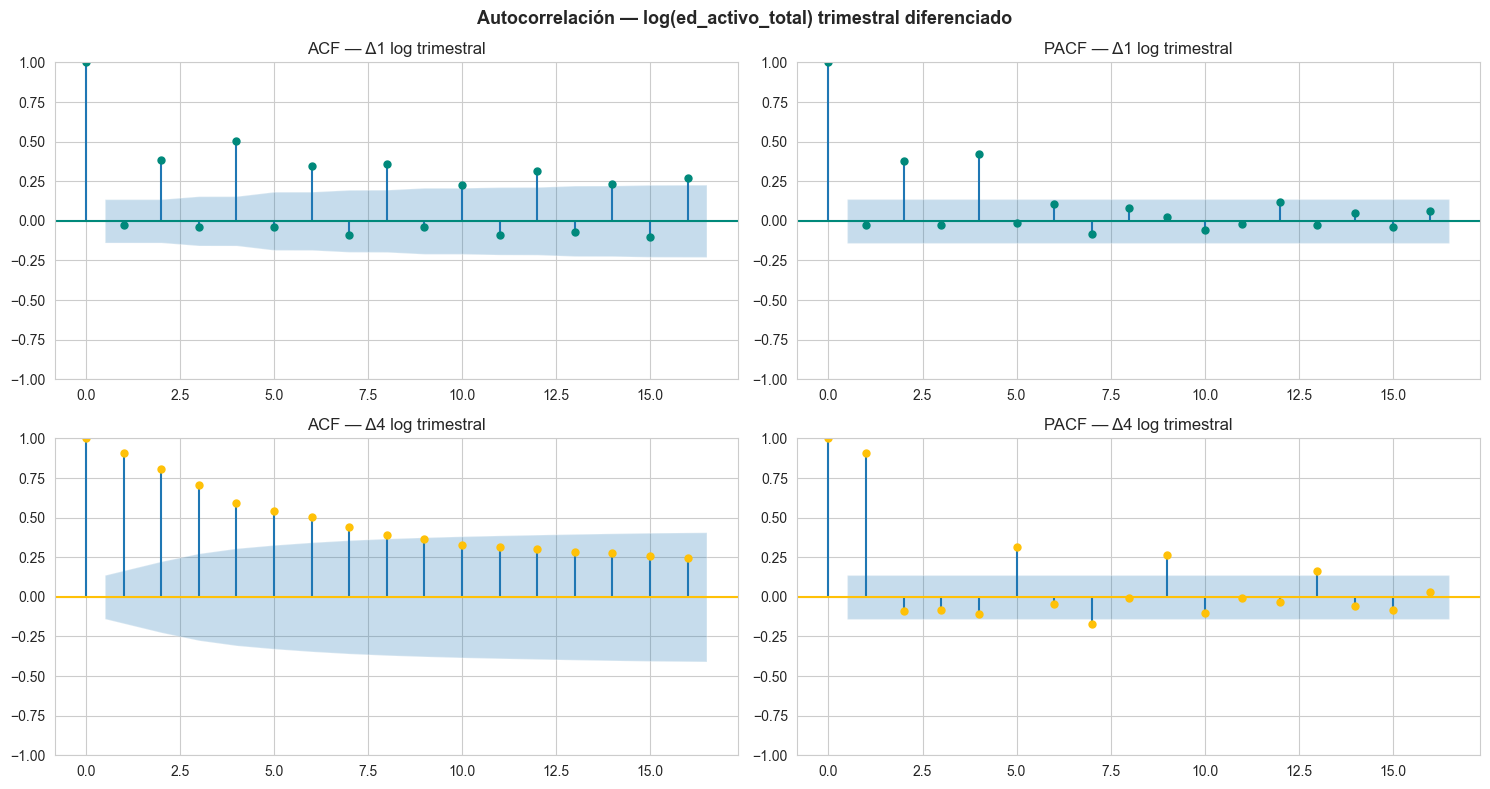

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f'Autocorrelación — log({VAR_PRINCIPAL}) trimestral diferenciado', fontsize=13, fontweight='bold')

plot_acf(log_diff1_q, lags=LAGS_ACF_Q, ax=axes[0, 0], color='#00897B',
         title='ACF — Δ1 log trimestral')
plot_pacf(log_diff1_q, lags=LAGS_ACF_Q, ax=axes[0, 1], color='#00897B',
          title='PACF — Δ1 log trimestral', method='ywm')
plot_acf(log_diff4_q, lags=LAGS_ACF_Q, ax=axes[1, 0], color='#FFC107',
         title='ACF — Δ4 log trimestral')
plot_pacf(log_diff4_q, lags=LAGS_ACF_Q, ax=axes[1, 1], color='#FFC107',
          title='PACF — Δ4 log trimestral', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

Los correlogramas de las series logarítmicas diferenciadas a frecuencia trimestral reproducen el patrón de sus equivalentes sin log, lo que confirma que la persistencia es independiente de la transformación de varianza. En la Δ1 del logaritmo, la ACF mantiene varios lags por encima de la banda, con un pico destacado en el lag 4 (aproximadamente +0,50) que señala estacionalidad anual residual, acompañado de valores significativos en los lags 2 y 6. La PACF reproduce el patrón con picos en los lags 2 y 4 (aproximadamente +0,38 y +0,42), confirmando que la primera diferencia del logaritmo deja estructura tanto de corto plazo como estacional.

En la Δ4 del logaritmo, la ACF mantiene el decaimiento lento desde valores próximos a 0,91, perfil característico de no estacionariedad, y la PACF queda dominada por un pico en el lag 1 (aproximadamente +0,91) con un secundario en el lag 5 (aproximadamente +0,32).

La equivalencia entre los correlogramas con y sin transformación logarítmica, a frecuencia trimestral igual que a frecuencia mensual, demuestra que la persistencia del activo bancario es una propiedad estructural del proceso que ninguna de las transformaciones evaluadas elimina. La búsqueda de una forma estacionaria de la serie no encuentra en la log una solución mejor que en las diferencias directas.

---
## 7. Variables Derivadas Intra-Dataset
Ratios y transformaciones calculadas a partir de las columnas de este dataset.

In [28]:
df_der = pd.DataFrame(index=df.index)

if all(c in df.columns for c in ['ed_activo_credito_sector_privado', 'ed_activo_total']):
    df_der['credito_privado_share'] = df['ed_activo_credito_sector_privado'] / df['ed_activo_total'] * 100
    df_der['crecimiento_credito_yoy'] = df['ed_activo_credito_sector_privado'].pct_change(12) * 100

print(f'Variables derivadas creadas ({len(df_der.columns)}):')
display(df_der.describe().round(3))

Variables derivadas creadas (2):


,credito_privado_share,crecimiento_credito_yoy
count,616.000,604.000
mean,48.842,2.893
std,9.581,7.928
min,36.568,-14.566
25%,40.592,-3.181
50%,47.406,2.061
75%,54.472,8.935
max,70.370,24.477


### Análisis:

Las dos variables derivadas capturan dimensiones complementarias de la estructura y dinámica del balance bancario. El `credito_privado_share` mide el peso del crédito al sector privado sobre el activo total y oscila entre un mínimo de 36,57% y un máximo de 70,37%, con media 48,84% y desviación típica 9,58 puntos porcentuales. El rango amplio anticipa que la composición del balance no es estable a lo largo del periodo. La distribución es ligeramente asimétrica a la baja: la mediana en 47,41% queda por debajo de la media y el rango intercuartílico (40,59% a 54,47%) se concentra en valores moderados, dejando los registros del extremo histórico cercanos al 70% como cola superior.

El `crecimiento_credito_yoy` mide la variación interanual porcentual del stock de crédito y presenta un rango de -14,57% a +24,48%, con media 2,89% y desviación típica 7,93 puntos porcentuales. La media positiva confirma que el periodo neto es de expansión crediticia, pero la magnitud de la desviación típica frente a la media indica que los regímenes de contracción tienen peso suficiente para hacer la dispersión comparable al propio nivel medio. La distribución de cuartiles (-3,18%, 2,06%, 8,94%) muestra que aproximadamente un cuarto de las observaciones registra contracción crediticia interanual, hallazgo coherente con la persistencia cíclica del activo total documentada en los tests de estacionariedad.

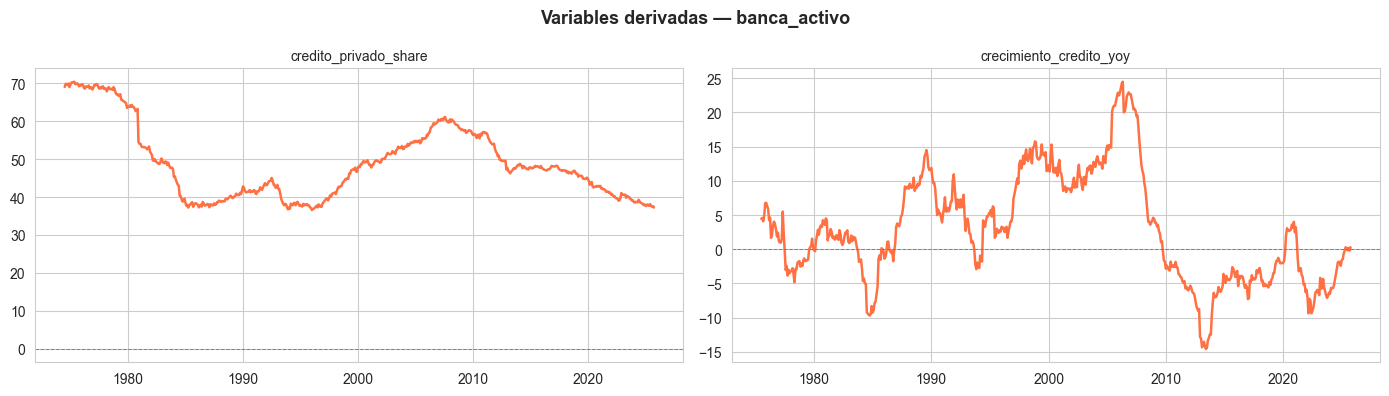

In [29]:
if not df_der.empty and len(df_der.columns) > 0:
    ncols = min(2, len(df_der.columns))
    nrows = (len(df_der.columns) + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(f'Variables derivadas — {NOMBRE}', fontsize=13, fontweight='bold')

    for ax, col in zip(axes, df_der.columns):
        serie = df_der[col].dropna()
        ax.plot(serie.index, serie, color='#FF7043', lw=1.8)
        ax.axhline(0, color='gray', lw=0.7, linestyle='--')
        ax.set_title(col, fontsize=10)

    for ax in axes[len(df_der.columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Análisis:

La trayectoria temporal de ambas variables organiza la historia del balance bancario español en episodios estructurales coherentes con los grandes regímenes macrofinancieros del periodo.

El `credito_privado_share` arranca en niveles próximos al 70% en 1974-1980, refleja un modelo bancario tradicional centrado en la financiación al sector privado. Entre 1981 y 1985 cae bruscamente hasta valores en torno al 37%, descenso que coincide con la crisis bancaria de 1977-1985 y la reestructuración del sistema, durante la cual el peso de otras partidas del activo (interbancario y deuda pública) aumenta relativamente. La serie se mantiene estable alrededor del 38-40% durante toda la década de los 90 y vuelve a ascender desde 1997 hasta tocar un máximo cíclico próximo al 62% en 2007-2008, recorrido que corresponde con la convergencia hacia la zona euro y la expansión del crédito hipotecario. Desde 2008 el share desciende de forma continuada hasta el 37-38% al final de la muestra, reflejo del desapalancamiento prolongado de hogares y empresas no financieras.

El `crecimiento_credito_yoy` describe el ciclo crediticio con mayor resolución. Tras oscilaciones moderadas en los 70, la serie marca un mínimo cercano al -10% en 1984-1985, coherente con la crisis bancaria. Entra después en una fase expansiva intermitente con picos del 10-15% durante los 90 y alcanza su amplitud máxima en 2006-2007 con tasas próximas al +24%, el pico del boom inmobiliario. A continuación se produce el colapso más profundo de la muestra: una contracción interanual del -14,57% en 2013-2014, en el momento más severo del desapalancamiento posterior a la crisis financiera. El periodo 2015-2025 muestra oscilaciones de menor amplitud en torno al cero, sin recuperar todavía un régimen sostenido de crecimiento positivo del crédito.

La lectura conjunta confirma que el balance bancario español experimentó dos ciclos completos durante el periodo muestral, uno cerrado en 1985 y otro abierto a partir de 2008 cuyo desapalancamiento todavía no se considera concluido al final de la muestra.

In [30]:
# ── Guardar dataset enriquecido (trimestral) ───────────────────────────────────────
if not df_der.empty:
    for col in df_der.columns:
        df[col] = df_der[col]

# Remuestrear a frecuencia trimestral (last para saldos/stocks bancarios)
cols_num = [c for c in df.columns if df[c].dtype in ['float64', 'int64', 'float32']]
df_trimestral = df[cols_num].resample('QS').last()
df_trimestral = df_trimestral.dropna(how='all')

# Guardar CSV trimestral
ruta_q = ruta.parent / (ruta.stem + '_trimestral.csv')
df_trimestral.to_csv(ruta_q)
print(f'CSV trimestral guardado: {ruta_q.name}')
print(f'  Columnas: {len(df_trimestral.columns)}')
print(f'  Rango: {df_trimestral.index.min().date()} — {df_trimestral.index.max().date()}')
print(f'  Observaciones: {len(df_trimestral)} trimestres')


CSV trimestral guardado: ed_activo_historico_1962_2026_trimestral.csv
  Columnas: 15
  Rango: 1974-07-01 — 2025-10-01
  Observaciones: 206 trimestres


---
## 8. Tabla Resumen

In [31]:
est_q_nivel = resultados_q[resultados_q['serie'].str.contains('nivel')]['conclusion'].values[0]
est_q_d1 = resultados_q[resultados_q['serie'].str.contains(r'\(Δ1\)')]['conclusion'].values[0]
est_q_d4 = resultados_q[resultados_q['serie'].str.contains(r'\(Δ4\)')]['conclusion'].values[0]
est_q_pct = resultados_q[resultados_q['serie'].str.contains('var interanual')]['conclusion'].values[0]
est_q_logd1 = resultados_log_q[resultados_log_q['serie'].str.contains('Δ1 log')]['conclusion'].values[0]
est_q_logd4 = resultados_log_q[resultados_log_q['serie'].str.contains('Δ4 log')]['conclusion'].values[0]

if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):
    idx_max = indice_estacional.idxmax()
    idx_min = indice_estacional.idxmin()
else:
    idx_max = 'N/A'
    idx_min = 'N/A'

q1q, q3q = y_q.quantile(0.25), y_q.quantile(0.75)
iqr_q = q3q - q1q
outliers_q = y_q[(y_q < q1q - 1.5 * iqr_q) | (y_q > q3q + 1.5 * iqr_q)]

resumen = pd.DataFrame([{
    'Dataset':               NOMBRE,
    'Variable':              VAR_PRINCIPAL,
    'Frecuencia':            f'trimestral (resampleo: {METODO_Q})',
    'N obs original':        f"{len(y.dropna())} ({DATASET_CONFIG['frecuencia_original']})",
    'Rango':                 f'{y_q.index.min().date()} — {y_q.index.max().date()}',
    'N obs':                 len(y_q.dropna()),
    'Media':                 y_q.mean().round(2),
    'Mediana':               y_q.median().round(2),
    'Std':                   y_q.std().round(2),
    'CV (%)':                (y_q.std() / y_q.mean() * 100).round(1),
    'Mín (fecha)':           f'{y_q.min():.1f} ({y_q.idxmin().date()})',
    'Máx (fecha)':           f'{y_q.max():.1f} ({y_q.idxmax().date()})',
    'Outliers IQR':          len(outliers_q),
    '% faltantes (original)': f'{df[VAR_PRINCIPAL].isnull().mean()*100:.1f}%',
    'Estacionaria (nivel)':            est_q_nivel,
    'Estacionaria (Δ1)':               est_q_d1,
    'Estacionaria (Δ4)':               est_q_d4,
    'Estacionaria (var interanual %)': est_q_pct,
    'Estacionaria (Δ1 log)':           est_q_logd1,
    'Estacionaria (Δ4 log)':           est_q_logd4,
    'Periodo más alto':      idx_max,
    'Periodo más bajo':      idx_min,
}]).T

resumen.columns = ['Valor']
print('=' * 60)
print('TABLA RESUMEN (frecuencia trimestral)')
print('=' * 60)
print(resumen.to_string())

TABLA RESUMEN (frecuencia trimestral)
                                                                   Valor
Dataset                                                     banca_activo
Variable                                                 ed_activo_total
Frecuencia                       trimestral (resampleo: valor de cierre)
N obs original                                             616 (mensual)
Rango                                            1974-07-01 — 2025-10-01
N obs                                                                206
Media                                                        2093466.770
Mediana                                                      1759168.150
Std                                                          1274684.630
CV (%)                                                            60.900
Mín (fecha)                                        445449.8 (1974-07-01)
Máx (fecha)                                       4327079.9 (2012-01-01)
Outliers IQR 

### Análisis:

La tabla resumen a frecuencia trimestral consolida el `ed_activo_total` como serie de stock bancario altamente persistente y no estacionaria en todas las formas evaluadas. Sobre las 206 observaciones trimestrales (resampleadas por valor de cierre desde las 616 mensuales originales), la media se sitúa en 2,09 billones de EUR constantes 2025 frente a una mediana de 1,76 billones, asimetría positiva característica de un proceso que pasa la mayor parte de la muestra en niveles bajos y solo alcanza los valores altos en su tramo final. El coeficiente de variación del 60,9% recoge el recorrido completo entre el mínimo de 445.450 millones (1974) y el máximo de 4,33 billones (2012), casi un orden de magnitud. La ausencia de outliers IQR pese a esta dispersión confirma que los registros extremos son los tramos inicial y final de la tendencia, no anomalías puntuales.

El diagnóstico de estacionariedad es el rasgo definitorio de la serie: ninguna de las seis transformaciones evaluadas a frecuencia trimestral resulta estacionaria. El nivel y la variación interanual porcentual convergen sin ambigüedad en no estacionariedad. La primera diferencia y la diferencia interanual quedan en zona ambigua, sin rechazo de ninguno de los dos tests, clasificadas como no estacionarias por criterio conservador. Las transformaciones logarítmicas tampoco estacionarizan, y la contradicción ADF/KPSS sobre la diferencia primera del logaritmo, presente a frecuencia mensual y trimestral, identifica un cambio estructural en la tasa de crecimiento del activo bancario en torno a 2008, coherente con el quiebre del ciclo crediticio en la crisis financiera.

La persistencia es estructural, no un artefacto de varianza ni de frecuencia de muestreo. La equivalencia entre los correlogramas con y sin transformación logarítmica, a ambas frecuencias, demuestra que la dependencia temporal proviene de la naturaleza del ciclo crediticio, cuyas fases de expansión y contracción se extienden a lo largo de varios años y generan autocorrelación que ninguna diferenciación simple elimina. La estacionalidad trimestral, en cambio, es inexistente (coeficiente de variación entre trimestres del 0,53%), por lo que la no estacionariedad de la serie es de origen tendencial y cíclico, no estacional.

De cara al cruce con la tasa de paro y a la posterior construcción del panel de variables explicativas, la forma estacionaria de referencia para el `ed_activo_total` es la variación interanual porcentual. Aunque su diagnóstico formal es de no estacionariedad, es la transformación económicamente interpretable (tasa de crecimiento interanual del balance bancario), la que neutraliza la tendencia de nivel y mantiene los valores en un rango acotado y estable a lo largo de la muestra, y la directamente comparable con las tasas de crecimiento del resto de variables del panel. El cruce con el desempleo se realiza, por tanto, sobre esta transformación y no sobre el nivel, evitando la correlación espuria inducida por la tendencia compartida entre series no estacionarias.

---
## 9. Análisis Cruzado con Desempleo
Relación entre **Banca Activo** y el desempleo (EPA, desde 1976Q3).

In [32]:
ruta_parados_s9 = RUTA_BASE / 'parados_sexo_edad.csv'
df_par_s9 = pd.read_csv(ruta_parados_s9)
df_par_s9['fecha'] = pd.to_datetime(df_par_s9['fecha'])
df_par_s9 = df_par_s9.set_index('fecha').sort_index()
df_par_s9['tasa_paro_ambos_sexos_total'] = pd.to_numeric(
    df_par_s9['tasa_paro_ambos_sexos_total'], errors='coerce')

parados_aligned = df_par_s9['tasa_paro_ambos_sexos_total']
fecha_inicio_comun = max(parados_aligned.first_valid_index(), df.index.min())
parados_aligned = parados_aligned[parados_aligned.index >= fecha_inicio_comun]
df_resampled = df[[VAR_PRINCIPAL]].resample('QS').agg('last').dropna()

# ── Qué variable cruzar con desempleo ──────────────────────────
main_s9 = (df_resampled[VAR_PRINCIPAL] / df_resampled[VAR_PRINCIPAL].shift(4) - 1) * 100   # variación interanual %
main_s9_label = f'Var. interanual % {VAR_PRINCIPAL}'
main_s9 = main_s9[main_s9.index >= fecha_inicio_comun].dropna()

print(f'Variable de cruce: {main_s9_label}')
print(f'Periodo común: {fecha_inicio_comun.date()} en adelante')
print(f'Observaciones alineadas: {len(main_s9)}')

Variable de cruce: Var. interanual % ed_activo_total
Periodo común: 1976-07-01 en adelante
Observaciones alineadas: 198


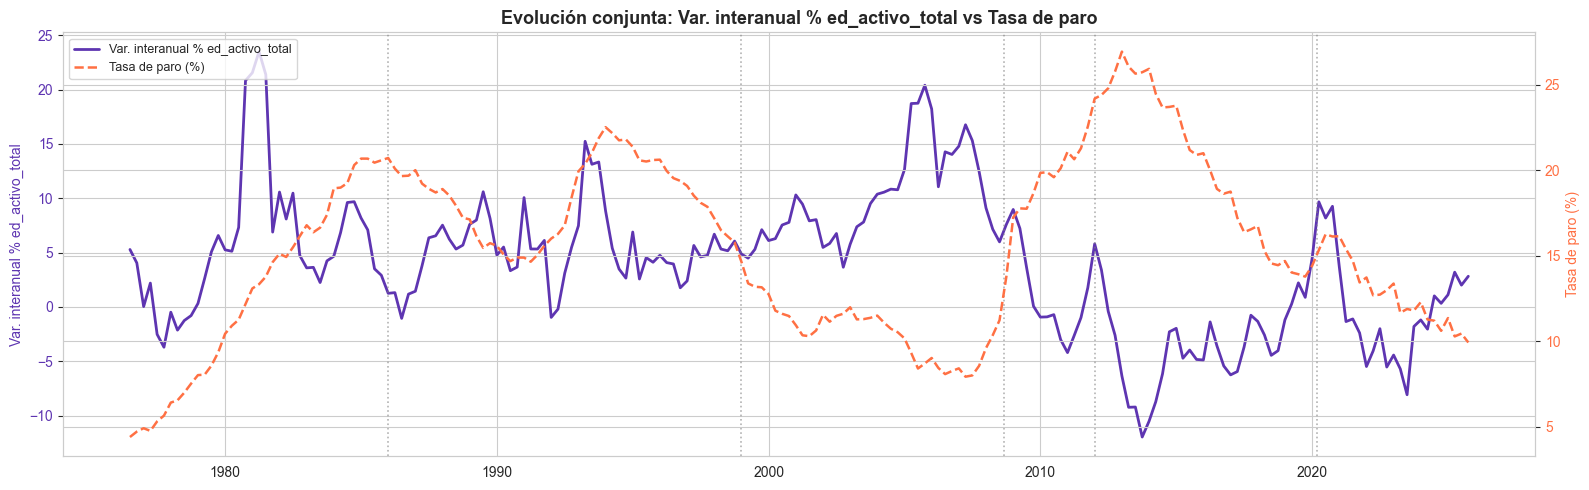

In [33]:
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(main_s9.index, main_s9, color=COLOR_PRINCIPAL, lw=2,
         label=main_s9_label)
ax2.plot(parados_aligned.index, parados_aligned, color='#FF7043',
         lw=1.8, linestyle='--', label='Tasa de paro (%)')

ax1.set_ylabel(main_s9_label, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')

for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if main_s9.index.min() <= fecha_ev <= main_s9.index.max():
        ax1.axvline(fecha_ev, color='gray', linestyle=':', lw=1.2, alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title(f'Evolución conjunta: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis:

La variación interanual % de `ed_activo_total` y `tasa_paro_ambos_sexos_total` exhiben una relación inversa visible a lo largo de toda la muestra. El paro recorre desde valores cercanos al 5% a mediados de los setenta hasta máximos próximos al 27% en 2013, con un segundo máximo de aproximadamente 22% en 1994 y un mínimo intermedio cercano al 8% en 2007, mientras la variación interanual del activo bancario alterna regímenes positivos y negativos en una banda aproximada de -12% a 23%. Los picos de crecimiento del activo, próximos al 23% en 1981, al 15% en 1994, al 20% en 2005-2006 y al 17% en 2007, coinciden con tramos de paro descendente o estabilizado, mientras que las contracciones más profundas, próximas al -12% en 2013 y por debajo del -5% en 2023, se sitúan en los periodos de paro elevado o creciente. La relación no es contemporánea estricta y muestra desfases que se cuantifican en los bloques siguientes. La caracterización de la relación se completa en la fase de feature engineering.

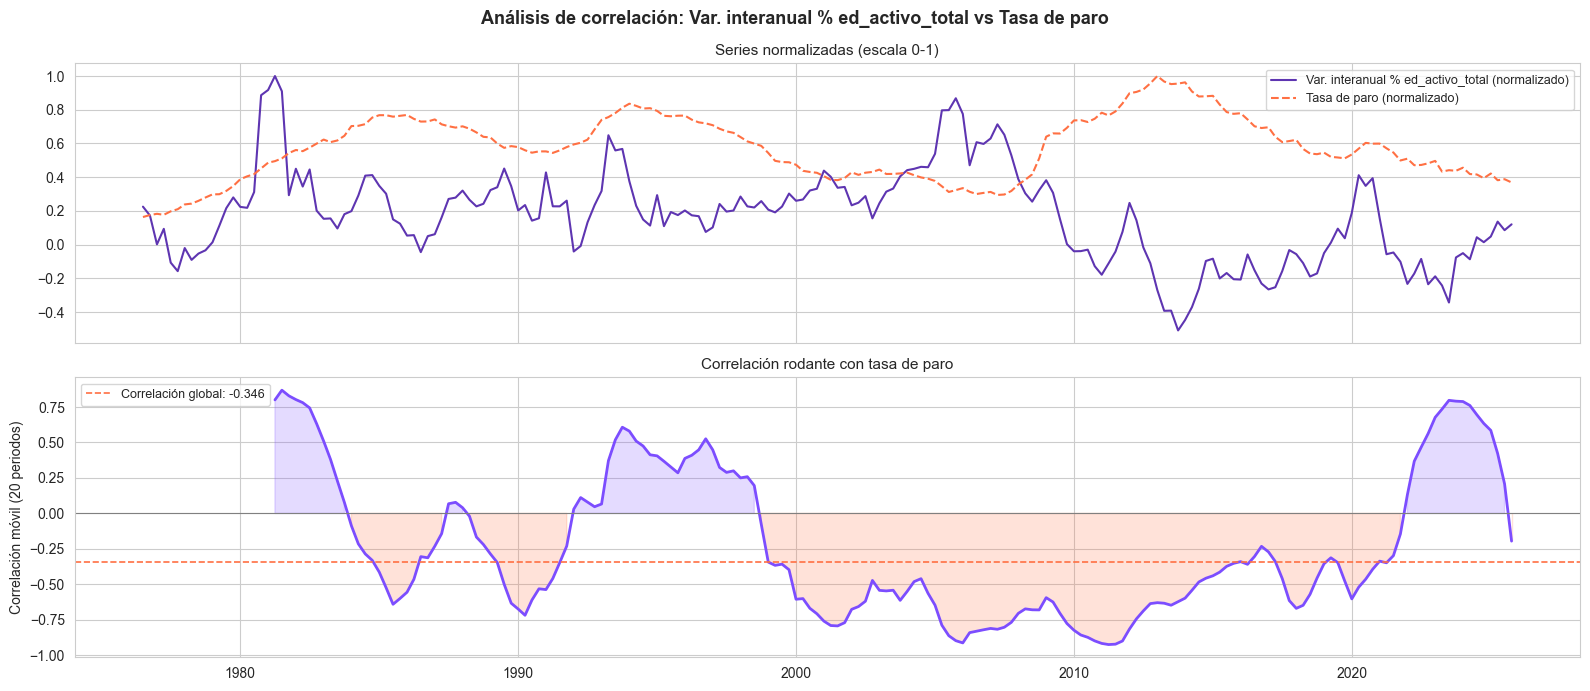

Correlación de Pearson global: -0.3458


In [34]:
ventana_corr = 20

df_cross = pd.DataFrame({'banca_activo': main_s9, 'parados': parados_aligned}).dropna()
rolling_corr = df_cross['banca_activo'].rolling(ventana_corr).corr(df_cross['parados'])
corr_global = df_cross['banca_activo'].corr(df_cross['parados'])

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df_cross.index, df_cross['banca_activo'] / df_cross['banca_activo'].max(),
             color=COLOR_PRINCIPAL, lw=1.5, label=f'{main_s9_label} (normalizado)')
axes[0].plot(df_cross.index, df_cross['parados'] / df_cross['parados'].max(),
             color='#FF7043', lw=1.5, linestyle='--', label='Tasa de paro (normalizado)')
axes[0].legend(fontsize=9)
axes[0].set_title('Series normalizadas (escala 0-1)', fontsize=11)

axes[1].plot(rolling_corr.index, rolling_corr, color='#7C4DFF', lw=2)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axhline(corr_global, color='#FF7043', lw=1.2, linestyle='--',
                label=f'Correlación global: {corr_global:.3f}')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr > 0, alpha=0.2, color='#7C4DFF')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr < 0, alpha=0.2, color='#FF7043')
axes[1].set_ylabel(f'Correlación móvil ({ventana_corr} periodos)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_title('Correlación rodante con tasa de paro', fontsize=11)

fig.suptitle(f'Análisis de correlación: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Correlación de Pearson global: {corr_global:.4f}')

### Análisis:

La correlación de Pearson global entre la variación interanual % de `ed_activo_total` y `tasa_paro_ambos_sexos_total` es de -0,3458, valor moderado que enmascara una correlación rodante (ventana 20 periodos) muy inestable en signo y magnitud. La correlación móvil recorre un rango aproximado entre -0,90 y +0,85: alcanza valores cercanos a +0,85 en 1981-1982, próximos a +0,60 en 1993-1995, próximos a +0,50 en 1996-1997 y un nuevo máximo cercano a +0,80 en 2022-2023, y por el lado negativo desciende a valores próximos a -0,75 en 1985-1990, a -0,85 entre 2000 y 2002, a -0,90 en torno a 2010-2012 y a -0,55 en 2016-2017. La correlación rodante cruza el cero en múltiples ocasiones y permanece por encima y por debajo de la global de -0,3458 durante tramos prolongados de la muestra. La inestabilidad indica que la relación lineal entre el crecimiento interanual del activo y el paro depende del régimen económico, no es contemporánea estable, y se caracteriza mejor en términos de tramos diferenciados que de una correlación única.

In [35]:
df_cross['decada'] = (df_cross.index.year // 10 * 10).astype(str) + 's'
paleta_decadas = ['#1565C0', '#00897B', '#FF7043', '#7C4DFF', '#FFC107', '#AD1457']

df_scatter = df_cross.reset_index().rename(columns={'index': 'fecha', df_cross.index.name or 'index': 'fecha'})
if 'fecha' not in df_scatter.columns:
    df_scatter.insert(0, 'fecha', df_cross.index.strftime('%Y-%m-%d'))
else:
    df_scatter['fecha'] = pd.to_datetime(df_scatter['fecha']).dt.strftime('%Y-%m-%d')

fig = px.scatter(
    df_scatter, x='banca_activo', y='parados',
    color='decada',
    hover_data=['fecha'],
    trendline='ols',
    trendline_scope='overall',
    color_discrete_sequence=paleta_decadas,
    title=f'Dispersión por década: {main_s9_label} vs Desempleo',
    labels={
        'banca_activo': main_s9_label,
        'parados': 'Tasa de paro (%)',
        'decada': 'Década', 'fecha': 'Fecha',
    },
)
fig.for_each_trace(lambda t: t.update(name='Tendencia global') if t.name == 'Overall Trendline' else None)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_layout(height=520)
fig.show()

### Análisis:

La dispersión por décadas confirma la heterogeneidad de la relación detectada en la correlación rodante y matiza el signo global negativo. La tendencia global representa una pendiente decreciente desde aproximadamente 20% de paro en variaciones interanuales del activo cercanas a -12% hasta aproximadamente 10% en variaciones próximas a +25%, consistente con la correlación global de -0,346. La nube de puntos, no obstante, presenta una superposición elevada entre décadas: los años 1970 (azul) y 2000 (morado) se concentran en la zona de paro bajo, entre el 5% y el 12%, con variaciones del activo entre 0% y +15%; los años 1980 (verde) y 1990 (naranja) ocupan la franja intermedia, con paro entre el 13% y el 22% y variaciones del activo entre -5% y +20%; los años 2010 (amarillo) se sitúan en la parte alta del paro, entre el 17% y el 27%, con variaciones del activo predominantemente negativas o ligeramente positivas; los años 2020 (rosa) se reparten en la franja del 10% al 16% de paro con variaciones del activo entre -10% y +10%. La dispersión interna de cada década es elevada y la relación lineal global captura solo una parte del cruzado. La caracterización completa se resuelve en la fase de feature engineering.

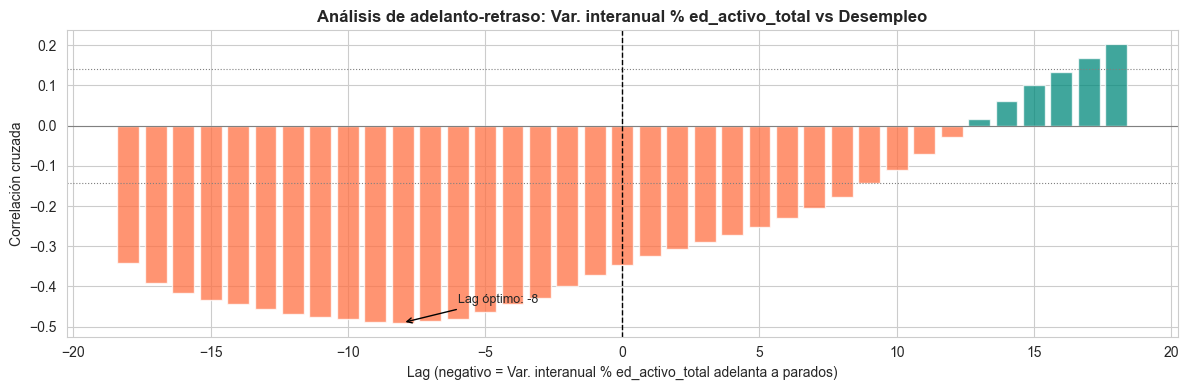

Lag con máxima correlación: -8 periodos
Correlación en ese lag: -0.4903
Banda de significancia (±2/√N): ±0.1421


In [36]:
max_lag = LAGS_ACF // 2

sa = (df_cross['banca_activo'] - df_cross['banca_activo'].mean()) / df_cross['banca_activo'].std()
sb = (df_cross['parados'] - df_cross['parados'].mean()) / df_cross['parados'].std()

lags_range = range(-max_lag, max_lag + 1)
ccf_vals = [sa.corr(sb.shift(-lag)) for lag in lags_range]

fig, ax = plt.subplots(figsize=(12, 4))
colors_ccf = ['#00897B' if v > 0 else '#FF7043' for v in ccf_vals]
ax.bar(list(lags_range), ccf_vals, color=colors_ccf, alpha=0.75)
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='black', lw=1, linestyle='--')
sig = 2 / np.sqrt(len(df_cross))
ax.axhline(sig, color='gray', lw=0.8, linestyle=':')
ax.axhline(-sig, color='gray', lw=0.8, linestyle=':')

lag_max = list(lags_range)[np.argmax(np.abs(ccf_vals))]
ax.annotate(f'Lag óptimo: {lag_max}', xy=(lag_max, ccf_vals[lag_max + max_lag]),
            xytext=(lag_max + 2, ccf_vals[lag_max + max_lag] + 0.05),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel(f'Lag (negativo = {main_s9_label} adelanta a parados)', fontsize=10)
ax.set_ylabel('Correlación cruzada', fontsize=10)
ax.set_title(f'Análisis de adelanto-retraso: {main_s9_label} vs Desempleo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Lag con máxima correlación: {lag_max} periodos')
print(f'Correlación en ese lag: {ccf_vals[lag_max + max_lag]:.4f}')
print(f'Banda de significancia (±2/√N): ±{sig:.4f}')

### Análisis:

El análisis de adelanto-retraso identifica un lag óptimo de -8 periodos con correlación cruzada de -0,4903, frente a una banda de significancia de ±0,1421. El signo negativo del lag indica que la variación interanual % de `ed_activo_total` adelanta a `tasa_paro_ambos_sexos_total`: los cambios en el crecimiento del activo bancario preceden en aproximadamente ocho trimestres a los movimientos en sentido opuesto del paro. La correlación cruzada permanece negativa y por encima de la banda de significancia en sentido absoluto en todo el tramo de lags negativos desde aproximadamente -18 hasta -3, con una meseta entre -12 y -6 en valores próximos a -0,48, y se mantiene negativa pero menos intensa en los lags contemporáneos y positivos cortos. A partir del lag +13 los coeficientes cambian de signo y alcanzan valores positivos próximos a +0,20 en los lags más largos, dentro o cerca de la banda de significancia. La estructura temporal es coherente con una relación inversa adelantada del crecimiento del activo respecto al paro, con una ventana de adelanto amplia centrada en torno a los ocho trimestres. La caracterización completa de la relación temporal se resuelve en la fase de feature engineering.